In [1]:
import pandas as pd
import numpy as np
from function_class import summarize_dataframe, na_summary, duplicate_summary, outlier_summary

    # 1. 분석목적
# 분석목적: 본 보고서는 당사의 구독 서비스를 이용하는 고객의 이탈 예
# 6측 및 이탈 핵심 요인 변수 파악에 있으며 이를 통해 향후 이탈 위험 고객 군을 분류하고 이들에게 별도의 이탈 방지 서비스를 제공하는 데에 있다. 즉, 이탈 위험 고객군 분류 및 비즈니스 의사결정을 위한 객관적 근거 제공이 목적이라 할 수 있다.
# 사용 데이터는 지난 한달 간의 서비스 실사용 고객 데이터를 기반으로 하며, 모델링의 안정성과 성능을 고려하여 랜덤 포레스트 알고리즘을 사용하였다.


churn_df = pd.read_csv(r'C:\Machine\streaming_churn_data.csv', low_memory=False)
columns_without_id = churn_df.columns[1: ]
churn_df = churn_df.loc[:, columns_without_id].copy()
summarize_dataframe(churn_df)

    #결측치 확인
print(na_summary(churn_df))
na_columns = ['monthly_fee', 'satisfaction_score', 'avg_watch_hours', 'payment_method']
print()

    #중복치 확인
print(duplicate_summary(churn_df))
#중복행 없음
print()

    #이상치 확인
print(outlier_summary(churn_df))

print(churn_df.columns[churn_df.isna().any(axis=0)])

c:\Users\박중현\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Machine\\streaming_churn_data.csv'

In [2]:
    #결측치 처리
# 결측치 탐색을 위한 EDA 분석 결과, 결측치는 총 4개의 특성(['payment_method', 'monthly_fee', 'avg_watch_hours','satisfaction_score']에 걸쳐 나타났으며,
# 결측치를 포함한 샘플의 counts는 2989개, 비율로는 전체 약 20%를 차지하는 것으로 확인되었다. 결측치의 비율을 고려했을 때,  단순 제거 방식은 데이터 손실과 모델 성능 저하를 유발할 위험이 있다.
# 따라서 샘플별, 데이터 특성별 대푯값으로 대체하는 방식을 사용하되, 대푯값에 의한 결측치 대체 방식은 또 다른 데이터 손실과 왜곡을 발생시킬 수 있으므로 결측변수의 내/외부 추가 분석을 통해 손실 위험을 보완할 필요가 있다.


#(1) 결측치 칼럼 별 '0' 유무 확인
for col in na_columns:
    zero_sum = (churn_df[col] == 0).sum()
    print(f'{col} 샘플 값 0 개수: {zero_sum}') 
print()
#결측치 포함 칼럼에서 value = 0 인 샘플은 발견되지 않았다. 따라서 결측치가 단순 결측이 아닌 0일 가능성을 배제할 수 없다. 이에 대한 판단은 결측집단 간 공결측 패턴 분석과 비결측 집단 변수와의 연관성 분석을 통해 종합적인 판단이 요구된다.


#(2) 결측치 칼럼 간 공결측 패턴 분석
from function_class import na_copattern
na_copattern(churn_df)
# 공결측 패턴 및 결측의 구조적 원인 유무를 확인하기 위해 결측집단 간 분포 counts와 rates를 분석했다. 분석 결과, 결측치는 단독 발생이 가장 많았고 변수 간 동행적인 요인 및 구조적 패턴이 있다고 단정할 근거는 제한적이었다.
# 결측치는 대부분 단독 발생(약 94%)했으며 중복으로 발생한 결측치는 전체 샘플 대비 약 0.06% - 2%대에 머물렀다.
# 따라서 결측치 발생 배후에 구조적인 요인이 있었다고 보기 어려우며, 결측치는 대부분 단독 발생했을 가능성이 높다.
# 이에 따라 추가 분석을 통해 외부 변수(비결측 집단 과의 비교)와의 연관성 파악을 요하며, 데이터 입력 시간과 결측치 발생 연관 여부를 파악하기 위한 추가적인 분석이 필요할 수 있다.


from function_class import na_profile, check_target, target_profile, na_association_profile


#(4)결측집단 프로파일링
na_profile(churn_df)
# 결측 집단의 특성을 파악하기 위해 칼럼별 결측집단 프로파일링을 시행했다. 비교 변수가 수치형인 경우 mean, median을 중심으로 standard를 보충하여 분석하였고, 범주형일 경우 결측/비결측 간 분포 비율을 중심으로 분석했다.
# 분석 결과, 비결측 집단에 대한 결측 집단의 특성은 명확하게 나타나지 않았으며, 이로부터 외부 변수가 결측 여부에 주요한 영향을 끼쳤다고 보기에는 근거가 제한적이다.


# 비결측 변수 별 결측 집단과 연관성 분석
num_cols_bin = churn_df.columns[churn_df.nunique(dropna=True) >= 8]
cat_cols_bin = churn_df.columns[churn_df.nunique(dropna=True) < 8]
na_association_profile(churn_df, num_cols_bin, cat_cols_bin, 5)
    #수치형
    #범주형
# 비결측 외부 변수의 결측의 결정 요인 가능성을 검토하기 위해 비결측변수와 결측변수 간 연관 관계를 분석했다. 
# 수치형의 경우 q-cut=5를 기준으로 분위수 단위 구간을 설정해 각 구간 별 결측치의 비율을 비교 검토했으며, 범주형의 경우 변수 내 서로 다른 항목들 간의 결측치 비율을 검토했다.  
# 변수 간 비율 차이의 정도를 해석함에 있어서는, 수치형 변수의 경우 집단 간 평균차이를 Cohen's d를 활용했으며(|d| ≥ 0.7), 범주형 변수는 집단 간 비율 차이를 절대 차이(≥ 10%p)와 상대 차이(≥ 1.5배) 및 최소 표본수(n ≥ 20) 기준으로 해석을 보정했다.
# 분석 결과, subscribtion_type이 Basic일 경우 다른 항목 대비 monthly_fee으 ㅣ결측이 약 2배 정도 높게 나타났으며(Basic: 10.6%, Premium: 5.5%, Standard: 4.8%), 앞선 결측 프로파일링에서는 동일 구독 유형의 결측 비율이 비결측 집단에 비해 20%p 가량 높게 나타났다(64%).
# 이상의 분석을 종합했을 때, 구독 유형 Basic과 월 비용 결측은 일정 수준의 연관관계가 있다고 볼 합리적 근거가 있으며, 결측 집단 중 Basic 구독 유형이 절반 초과인 64%가 된다는 점을 감안 했을 때, 해당 구독유형의 고객 데이터 프로세스상 문제 발생 가능성을 의심할 수 있다. 
# basic 구독자에서 월비용 결측 비율이 높게 나타난 것은 basic 요금제가 주로 무료 체험 및 프로모션과 연결되어 실제 청구 정보가 없거나(0원) 저장되지 않는 경우가 많기 떄문일 가능성이 있다. 또한 간편 가입 등 정보 수집 강도가 낮은 유입 경로가 basic에 집중 되었을 가능성도 있다. 다

# 월비용 결측 집단 내 베이직 구독자의 비율
# [na_monthly_fee vs subscription_type]
# na_monthly_fee            결측집단         비결측집단
# subscription_type                           
# Basic              727(64.00%)  6119(44.14%)
# Premium            147(12.94%)  2526(18.22%)
# Standard           262(23.06%)  5219(37.64%)

# 베이직 구독자 중 월비용 결측 비율
# [na_monthly_fee vs subscription_type]
# na_monthly_fee           결측집단        비결측집단
# subscription_type                         
# Basic              727(10.6%)  6119(89.4%)
# Premium             147(5.5%)  2526(94.5%)
# Standard            262(4.8%)  5219(95.2%)


#결측치 처리
print(churn_df.columns[churn_df.isna().any(axis=0)])

# 이상의 결측치 집단에 대해 수행한 분석을 종합했을 때, 결측치를 0으로 볼 명확한 근거가 없으며, 결측 집단 간 그리고 비결측 집단 사이에 뚜렷한 패턴이나 연관성은 찾아볼 수 없었다.
# 이에 따라 결측치 처리는 변수의 개별적인 특성을 반영하여 처리하였다.평균 시청 시간은 중간값으로 대체하여 왜곡을 최소화 하였고, 결제 방식의 경우 범주형 변수임을 고려해 새로운 값 'unknown'으로 대체했다.
# # 월 비용은 구독 유형과 밀접한 선형관계를 가지고 있어 구독 유형별 중간값으로 대체하였고, 만족도 점수는 결측치 빈도율이 0.7%로 낮은 점, 해당 분석 결과와 밀접한 관계를 맺을 것으로 예상하여 삭제 처리함으로써 왜곡을 최소화 하고자 했다.



monthly_fee 샘플 값 0 개수: 0
satisfaction_score 샘플 값 0 개수: 0
avg_watch_hours 샘플 값 0 개수: 0
payment_method 샘플 값 0 개수: 0

[NA co-pattern summary]
--------------------------------------------------
   payment_method monthly_fee avg_watch_hours satisfaction_score  NA_count  NA_rate(%)
0               X         NaN               X                  X       978   32.719973
1               X           X               X                NaN       905   30.277685
2               X           X             NaN                  X       498   16.661091
3             NaN           X               X                  X       371   12.412178
4               X         NaN               X                NaN        74    2.475744
5               X         NaN             NaN                  X        47    1.572432
6               X           X             NaN                NaN        34    1.137504
7             NaN           X               X                NaN        29    0.970224
8             NaN         N

In [3]:
print(churn_df.columns[churn_df.isna().any(axis=0)])

# 결측치 처리
(churn_df['subscription_type'] == 'Basic').mean()
print(churn_df.columns)

# 결측치 처리는 다음의 방식으로 수행하였다: 결제 방식의 경우, 시스템 상 구독 요금 이외의 비용이 청구되는 경우가 드물기 떄문에 월 비용의 구간 별(q-cut=5) 최빈값으로 결측치를 대체했다. 울 청구 비용의 경우 구독 유형이 민감한 변수로, 구독 유형별 중앙값으로 결측치를 대체했다.
# 평균시청시간은 주 로그인 일수와 밀접한 연관성을 갖고 있기 때문에 주 로그인 일수 별 평균값으로 대체했다.
# 만족도 점수는 결측치 비율이 전체 대비 약 7% 정도로 높지 않으며, 이탈/비이탈 여부를 결정하는 핵심 요인일 가능성이 있어 일괄 삭제처리 함으로써 모델 학습 왜곡을 최소화 하고자 했다.

print(churn_df['satisfaction_score'].isna().mean()) #7% 비율

# monthly_fee
churn_df['monthly_fee'] = churn_df['monthly_fee'].fillna(churn_df.groupby(by='subscription_type', dropna=True)['monthly_fee'].transform('median'))
print('월비용', churn_df['monthly_fee'].isna().sum())

# payment_method
df = churn_df.copy()
df['monthly_fee_bin'] = pd.qcut(churn_df['monthly_fee'], q=5)
churn_df['payment_method'] = df['payment_method'].fillna(df.groupby(by=['subscription_type', 'monthly_fee_bin'], dropna=True)['payment_method'].transform(lambda x: x.mode().iloc[0]))
print('구독유형', churn_df['payment_method'].isna().sum())

#avg_watch_hours
df['weekly_login_days_bin'] = pd.qcut(df['weekly_login_days'], q=5)
churn_df['avg_watch_hours'] = df['avg_watch_hours'].fillna(df.groupby(by='weekly_login_days_bin', dropna=True)['avg_watch_hours'].transform('median'))
print('평균시청시간', churn_df['avg_watch_hours'].isna().sum())

#satisfaction_score
churn_df['satisfaction_score_na'] = churn_df['satisfaction_score'].isna().astype('int')
churn_df['satisfaction_score']= df['satisfaction_score'].fillna(df.groupby(by='weekly_login_days_bin', dropna=True)['satisfaction_score'].transform('mean'))
print('만족도 점수', churn_df['satisfaction_score'].isna().sum())

churn_df['payment_method'].value_counts()

# 분석내용
# 결측치는 각 변수의 특성과 다른 변수와의 관련성을 반영하여 처리하였다. 
# 먼저 월비용(`monthly_fee`)은 구독유형에 따라 요금 수준이 구조적으로 달라질 수 있으므로, `subscription_type`별 중앙값으로 결측치를 대체하였다. 중앙값을 사용한 것은 일부 할인·프로모션 값 등으로 인한 극단값의 영향을 줄이기 위함이다.
# 결제방식(`payment_method`)은 구독유형과 월비용 수준에 따라 분포가 달라질 수 있다고 판단하였다. 이에 따라 월비용을 5개 구간으로 구분한 뒤, `subscription_type`과 결합한 범주별 최빈값으로 결측치를 대체하였다.
# 평균시청시간(`avg_watch_hours`)은 서비스 이용 빈도를 나타내는 주간 로그인 일수와의 관련성을 고려하여, `weekly_login_days` 구간별 중앙값으로 결측치를 대체하였다. 이를 통해 단순 일괄 대체보다 이용 패턴을 반영한 보완이 가능하도록 하였다.
# 만족도 점수(`satisfaction_score`)는 고객 이탈 예측에 중요한 설명변수일 가능성이 있으므로, 결측 여부를 나타내는 더미 변수를 추가하여 결측 자체의 정보도 함께 보존하였다. 또한 점수 범위가 1점에서 5점으로 제한되어 있어 극단값에 따른 왜곡 가능성이 상대적으로 낮다고 판단하여, `weekly_login_days` 구간별 평균값으로 결측치를 대체하였다.

Index(['payment_method', 'monthly_fee', 'avg_watch_hours',
       'satisfaction_score'],
      dtype='object')
Index(['age', 'gender', 'region', 'device_type', 'subscription_type',
       'payment_method', 'marketing_channel', 'tenure_months', 'monthly_fee',
       'avg_watch_hours', 'weekly_login_days', 'num_devices_registered',
       'num_profiles', 'support_tickets_6m', 'payment_failures_3m',
       'days_since_last_login', 'used_discount', 'auto_renew',
       'price_increase_recent', 'multi_service_user', 'satisfaction_score',
       'churn'],
      dtype='object')
0.07
월비용 0
구독유형 0
평균시청시간 0
만족도 점수 0


C:\Users\박중현\AppData\Local\Temp\ipykernel_3648\3156257565.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_df['payment_method'] = df['payment_method'].fillna(df.groupby(by=['subscription_type', 'monthly_fee_bin'], dropna=True)['payment_method'].transform(lambda x: x.mode().iloc[0]))
C:\Users\박중현\AppData\Local\Temp\ipykernel_3648\3156257565.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_df['avg_watch_hours'] = df['avg_watch_hours'].fillna(df.groupby(by='weekly_login_days_bin', dropna=True)['avg_watch_hours'].transform('median'))
C:\Users\박중현\AppData\Local\Temp\ipykernel_3648\3156257565.py

payment_method
CreditCard      6741
BankTransfer    3434
MobilePay       2618
KakaoPay        2207
Name: count, dtype: int64

Index(['age', 'tenure_months', 'monthly_fee', 'avg_watch_hours',
       'weekly_login_days', 'support_tickets_6m', 'days_since_last_login',
       'satisfaction_score'],
      dtype='object')

age_outlier_specific
------------------------------------------------------------
       age
209     75
8248    75
11338   75
6891    75
13225   75
...    ...
7783    67
11611   67
10457   67
13114   67
13246   67

[73 rows x 1 columns]
tenure_months_outlier_specific
------------------------------------------------------------
       tenure_months
14972             60
110               60
235               60
253               60
327               60
...              ...
4513              57
996               57
3508              57
3634              57
14159             57

[410 rows x 1 columns]
monthly_fee_outlier_specific
------------------------------------------------------------
       monthly_fee
11898     112750.0
6218      112540.0
5684      111475.0
4570      106605.0
4890      101925.

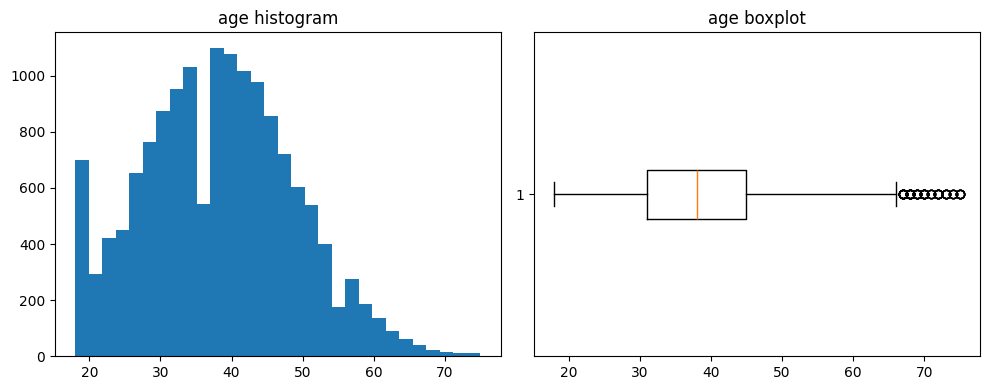

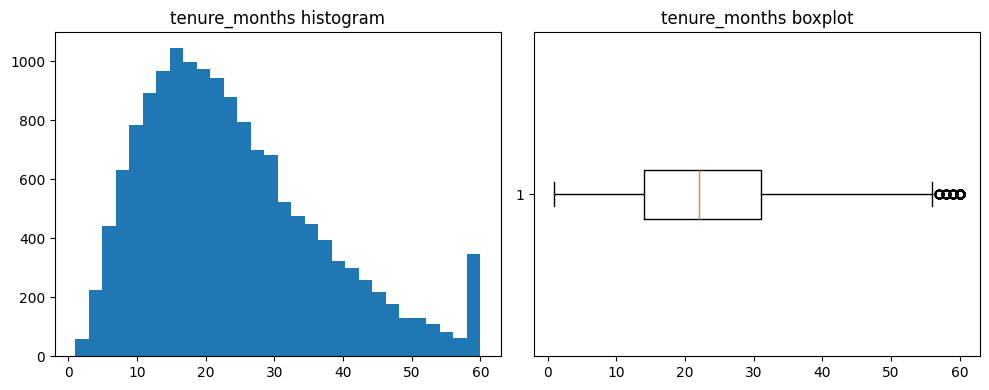

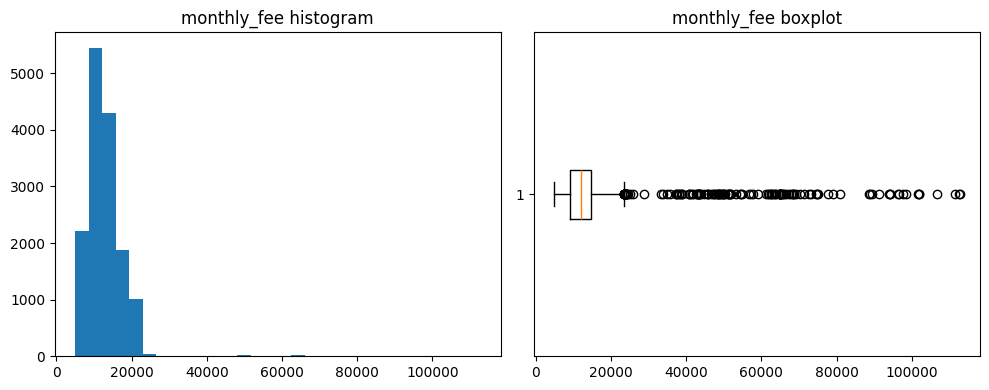

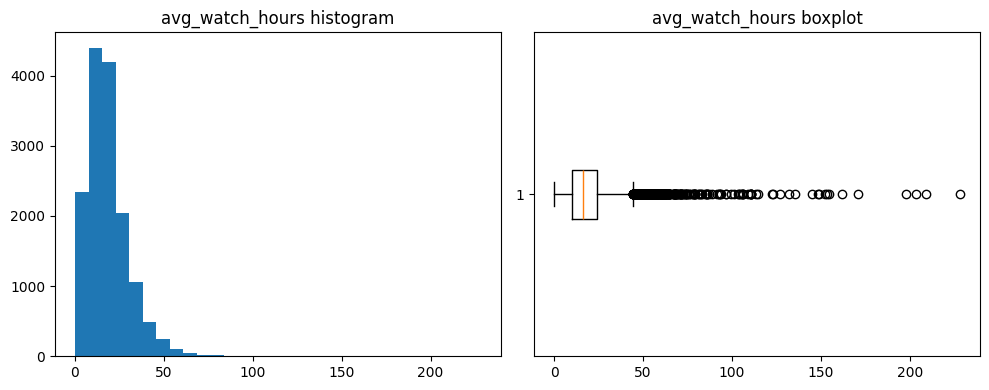

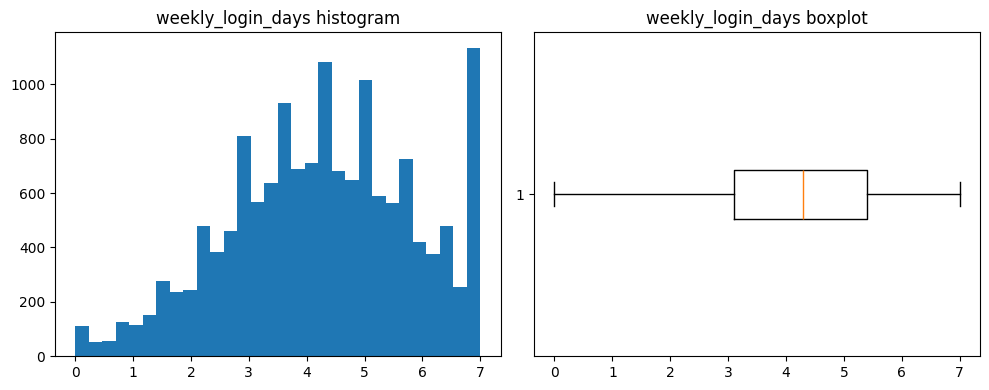

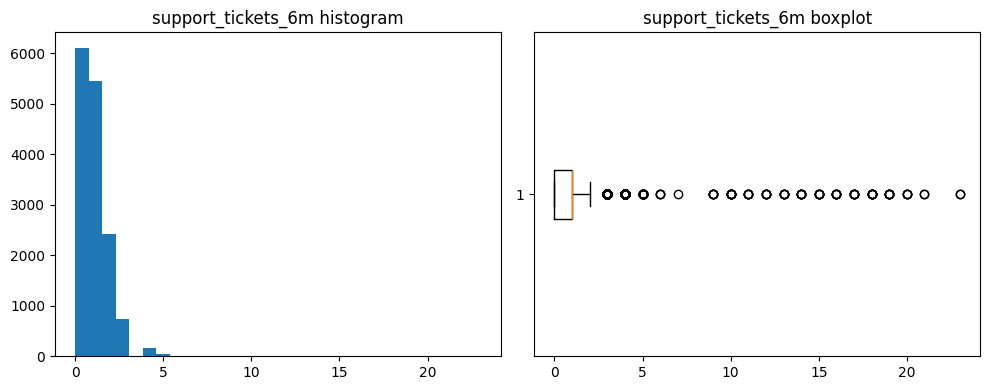

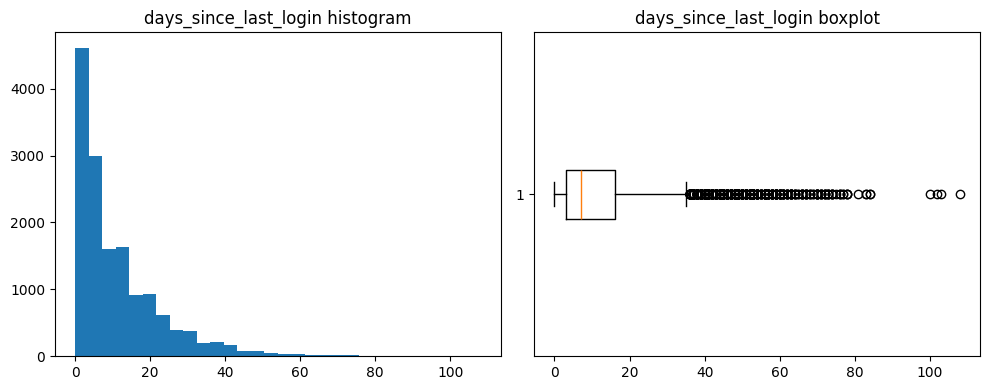

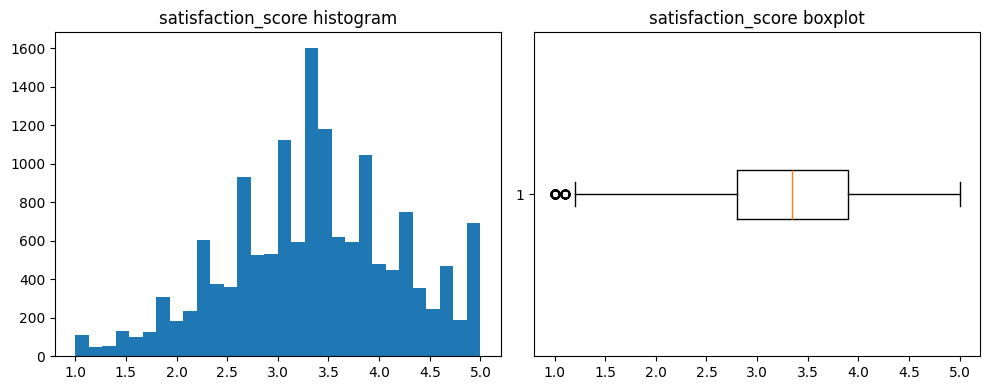

[outlier_summary]
--------------------------------------------------------------------------------
                       column   lower     upper  outlier_count  \
15                      churn    0.00      0.00           1405   
16      satisfaction_score_na    0.00      0.00           1050   
7          support_tickets_6m   -1.50      2.50           1013   
9       days_since_last_login  -16.50     35.50            718   
3   total_watch_hours_1months  -10.35     44.45            532   
1               tenure_months  -11.50     56.50            410   
8         payment_failures_3m   -1.50      2.50            174   
14         satisfaction_score    1.15      5.55            109   
5      num_devices_registered   -1.00      7.00            109   
0                         age   10.00     66.00             73   
2                 monthly_fee  462.50  23226.50              9   
6                num_profiles   -1.00      7.00              0   
4           weekly_login_days   -0.35      

In [4]:
#이상치 처리
from function_class import plot_numeric_distributions, iqr_outlier_bound_mask
num_out_cols = churn_df.columns[churn_df.nunique(dropna=True)>=10]
num_df = churn_df[num_out_cols].copy()
num_df.head()
print(num_out_cols)
print()

for col in num_out_cols:
    lower, upper, mask, outlier_df = iqr_outlier_bound_mask(num_df[col])
    print(f'{col}_outlier_specific')
    print('-'*60)
    print(outlier_df)
    print('='*60)
    
plot_numeric_distributions(num_df)
# 월청구 비용의 정의상 혼입 가능성 발견(10만원 이상의 비용 발생 다수). 구독 유형별 요금제 및 구독 이외의 별도 비용 발생 여부 검토 필요. 
# 평균 시청 시간 집계 기준 확인 필요. 정의상 혼입 가능성. 
# 평균 시청 시간: 최근 1개월 기준 이용량 지표로 설정된 변수이며, 일부 극단값은 이상치 상황을 반영하기 위해 의도적으로 포함되었다.
# 별도 요금 발생 여부: 데이터 정의상 구독 외 추가요금 구조는 명시적으로 반영하지 않았다.
# 월청구비용: 구독 유형별 월 구독료를 기준으로 생성한 변수이며, 비정상적으로 큰 값은 정상 청구라기보다 이상치 또는 집계 혼입으로 해석하는 것이 타당하다.
#평균시청시간이 아닌 총 시청시가능로 칼럼명 변경.
#월비용청구: 집계 혼입 가능성 높음 -> 구독요금제와 관련성 고려, 구독 요금제 별 중앙값 대체.

#평균시청시간 칼럼명 변경
churn_df = churn_df.rename(columns={'avg_watch_hours': 'total_watch_hours_1months'})

#월비용청구 이상치 처리
low, up, mask, fee_df = iqr_outlier_bound_mask(churn_df['monthly_fee'])
fee_median = churn_df.loc[~mask].groupby(by='subscription_type')['monthly_fee'].median()
churn_df.loc[mask, 'monthly_fee'] = churn_df.loc[mask, 'subscription_type'].map(fee_median)

#이상치 처리 결과확인
print(outlier_summary(churn_df))
#월비용청구 0.06%로 축소

#분석내용
# 랜덤 포레스트 모델은 극단값에 비교적 강건한 트리 기반 모델이므로, 본 분석에는 이상치 처리의 기계적 정제보다 데이터 품질 확보 및 불안정한 분할 방지에 초점을 두었다.
# IQR 기준 점검 결과, 일부 연속형 카운트형 변수에서 우측 꼬리가 긴 분포가 확인되었으나, 대부분 도메인 상 합리적 범위 내부에 있는 것으로 확인되어 일괄 제거 하지 않았다.
# 하지만 'avg_watch_hours'와 'monthly_fee' 변수에서 변수 정의상 모호한 점, 도메인 정책상 불가능한 값이 확인되어(월 비용 10만원 이상), 정의상*집계상 혼입 가능성을 배제할 수 없다 따라서 변수 정의 및 데이터 집계 방식을 추가 검토할 필요가 있다. 
# 검토 결과, 'avg_watch_hours'는 '최근 1개월 기준 이용량 지표'인 점을 감안해 'total_watch_hours_1months'로 변수명을 변경하였으며,
# 'monthly_fee'는 'subcription_type'을 기준으로 생성된 변수인 점을 감안해, 이상치를 제거한 구독 유형별 중앙값으로 대체, 일부 극단값의 영향을 최소화 하고 데이터 품질을 보존하고자 하였다.
# 처리 결과 monthly_fee 이상치는 기존 약 0.95%에서 0.06%로 줄어들었다.


In [5]:
#타깃군 분석 및 탐색
# 본 분석의 타겟 변수인 'churn' 집단의 대표값 및 방향성을 확인한다. 타겟 프로파일을 통해 타겟군과 비타겟 군의 구성비 차이를 확인하고, 각 변수와 타겟 군 간의 관계 분석을 통해 상호 연관성 정도를 확인한다.
# 이를 통해 고객 이탈 여부에 영향을 미칠 가능성이 있을 주요 변수들을 선제적으로 파악하는 것이 본 분석의 목적이다.

from function_class import target_profile, check_target

check_target(churn_df, 'churn')
target_profile(churn_df, 'churn', q=5)
# tenure_months    24.38    18.92
# total_watch_hours_1months    18.94    16.00
# days_since_last_login    10.81    13.51
# price_increase_recent     0.25     0.36
# satisfaction_score     3.38     3.01

# [churn vs subscription_type]
#                        churn=0     churn=1
# subscription_type                         
# Basic              6127(45.1%)  719(51.2%)
# Premium            2458(18.1%)  215(15.3%)
# Standard           5010(36.9%)  471(33.5%)

# [churn vs marketing_channel]
#                        churn=0     churn=1
# marketing_channel                         
# Ads                3275(24.1%)  397(28.3%)
# Affiliate          1436(10.6%)   139(9.9%)
# Organic            4188(30.8%)  429(30.5%)
# Referral           2222(16.3%)  229(16.3%)
# SNS                2474(18.2%)  211(15.0%)

# std
# tenure_months    13.23    10.75
# days_since_last_login    11.54    13.94

    # 타겟 프로파일링 분석결과
    # 타깃 샘플 분포 분석 결과, 카운트는 1405개, 약 9% 비율로 극단적 희소 클래스는 아니지만, 불균형 여부는 모델링을 통한 추가 검토가 필요할 것을으로 보인다. 
    # 타깃 집단의 구성비를 확인하기 위해 타깃 프로파일링을 진행하였으며, 수치형 변수의 경우 평균 및 중앙값 차이를 중심으로, 범주형 변수의 경우 변수 내 범주별 구성비를 검토했다.
    # 분석 결과, 이탈 집단(churn=1)은 tenure_moths, watch_hours_last_1month, satisfaction_score, SNS rate가 상대적으로 낮은 반면, days_since_last_login, price_increase_recent, Basic 구독, AD 유입 rate는 상대적으로 높게 나타났다.
    # 또한 이탈 집단은 가입 기간이 상대적으로 집중적으로 분포되어 있었으며(std: 13.23 / 10.75 ), 로그인 일수는 넓게 분포되어 있음을 관찰할 수 있었다.(11.54 / 13.94). 
    # 다만, 변수 특성상 평균 및 분포 차이만으로 중요도를 단정하기보다, 변수 구간 별 churn rate를 추가 검토할 필요가 있다.

# 변수 - 타겟 관계 분석
# [tenure_months -> churn]
#                        churn=0     churn=1
# tenure_months_bin                         
# (0.999, 12.0]      2594(85.5%)  441(14.5%)
# (12.0, 18.0]       2664(88.5%)  346(11.5%)
# (18.0, 25.0]       2908(90.8%)   296(9.2%)
# (25.0, 34.0]       2559(92.5%)   207(7.5%)
# (34.0, 60.0]       2870(96.1%)   115(3.9%)

# #tenure_months, Basic 구독유형 반비례 관계  시청시간 고객만족도 반비례관계, 고객문의 비례관계 결제 시폐 비례 로그인수 비례 

# [total_watch_hours_1months -> churn]
#                                    churn=0     churn=1
# total_watch_hours_1months_bin                         
# (0.199, 8.9]                   2640(87.3%)  384(12.7%)
# (8.9, 14.0]                    2654(88.9%)  333(11.1%)
# (14.0, 18.6]                   2767(91.3%)   263(8.7%)
# (18.6, 26.3]                   2731(91.9%)   241(8.1%)
# (26.3, 228.0]                  2803(93.8%)   184(6.2%)

# [support_tickets_6m -> churn]
#                              churn=0     churn=1
# support_tickets_6m_bin                          
# (-0.001, 1.0]           10605(91.8%)   951(8.2%)
# (1.0, 2.0]               2140(88.0%)  291(12.0%)
# (2.0, 23.0]               850(83.9%)  163(16.1%)

# [payment_failures_3m -> churn]
#                          churn=0     churn=1
# payment_failures_3m                         
# 0                    9332(92.0%)   815(8.0%)
# 1                    3368(88.8%)  425(11.2%)
# 2                     761(85.9%)  125(14.1%)

# [days_since_last_login -> churn]
#                                churn=0     churn=1
# days_since_last_login_bin                         
# (-0.001, 2.0]              3422(92.8%)   266(7.2%)
# (2.0, 5.0]                 2340(90.8%)   237(9.2%)
# (5.0, 10.0]                2687(91.1%)   262(8.9%)
# (10.0, 18.0]               2537(90.0%)  283(10.0%)
# (18.0, 108.0]              2609(88.0%)  357(12.0%)

# [price_increase_recent -> churn]
#                             churn=0     churn=1
# price_increase_recent                          
# 0                      10149(91.8%)   905(8.2%)
# 1                       3446(87.3%)  500(12.7%)

# [satisfaction_score -> churn]
#                             churn=0     churn=1
# satisfaction_score_bin                         
# (0.999, 2.6]            2603(84.7%)  470(15.3%)
# (2.6, 3.2]              2898(89.0%)  359(11.0%)
# (3.2, 3.5]              2583(92.7%)   202(7.3%)
# (3.5, 4.1]              2942(92.4%)   241(7.6%)
# (4.1, 5.0]              2569(95.1%)   133(4.9%)

# [subscription_type -> churn]
#                        churn=0     churn=1
# subscription_type                         
# Basic              6127(89.5%)  719(10.5%)
# Premium            2458(92.0%)   215(8.0%)
# Standard           5010(91.4%)   471(8.6%)

#   분석결과
#   클래스 집단 간 타깃층의 상대적 분포 차이를 검토하여 변수와 타깃 간의 연관성을 분석하였다. 수치형 변수의 경우 분위수를 기준으로 5개의 구간을 설정했고 범주형의 경우 value 별 타깃층 분포를 검토하였다. 
#   분석 결과, 가입기간, 최근 시청 시간, 만족도는 이탈율과 반비례하는 경향을 보였고, 고객 문의, 결제 실패, 로그인 공백, 최근 요금 인상 여부는 상대적 정비례 경향을 보였다. 또한 구독 유형 가운데 Basic에서 상대적으로 높은 churn rate가 나타났다. 
#   특히 tenure, satisfaction_score, days_since_last_login은 구간별 chrun rate 차이가 비교적 명확하며 일관된 단조성이 나타나 주요 후보 변수로 판단된다.
#   하지만, 본 분석은 기술통계 기반 탐색 결과이므로, 변수 중요도 확정은 모델 기반 중요도 분석 및 단변량 검정을 통해 추가 검증할 필요가 있다. 
#   


[Target Check]
target column: churn
--------------------------------------------------
       count  ratio
churn              
0      13595  90.63
1       1405   9.37
--------------------------------------------------
total rows: 15000
target ratio: 9.3667

[Target Imbalance Check]
majority class ratio: 90.6333
minority class ratio: 9.3667
baseline accuracy: 90.6333

[Target profile]
target: churn
[profiling summary]
[profiling summary - numeric]
--------------------------------------------------------------------------------
기준 충족 변수 없음

[profiling summary - categorical]
--------------------------------------------------------------------------------
기준 충족 변수 없음

[target profiling - numeric]
--------------------------------------------------------------------------------
[churn - mean]
                 variable  churn=0  churn=1
                      age    38.17    38.26
            tenure_months    24.38    18.92
              monthly_fee 12467.53 12007.36
total_watch_hours_1months 

In [6]:
# 4. 모델 훈련 및 검증
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, train_test_split

col_list = churn_df.columns.tolist()
col_list.remove('churn')
target = churn_df['churn']
input = churn_df.loc[:, col_list]

train_ii, test_i, train_tt, test_t = train_test_split(input, target, shuffle=True, stratify=target, test_size=0.2, random_state=42)
train_i, valid_i, train_t, valid_t = train_test_split(train_ii, train_tt, shuffle=True, stratify=train_tt, test_size=0.2, random_state=42)
print(train_i.shape, test_i.shape, valid_i.shape)

#원 핫 인코딩: 범주형 문자열 변수만
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

hot_cols = ['gender', 'region', 'device_type', 'subscription_type',
       'payment_method', 'marketing_channel']

hot_encode = ColumnTransformer(transformers = [('cat', OneHotEncoder(handle_unknown = 'ignore'), hot_cols)], remainder='passthrough')
train_h = hot_encode.fit_transform(train_i)
valid_h = hot_encode.transform(valid_i)
test_h = hot_encode.transform(test_i)
print(f'핫 인코딩 확인: {train_h.shape}')

train_h = pd.DataFrame(
    train_h,
    columns=hot_encode.get_feature_names_out(),
    index=train_i.index
)

valid_h = pd.DataFrame(
    valid_h,
    columns=hot_encode.get_feature_names_out(),
    index=valid_i.index
)

test_h = pd.DataFrame(
    test_h,
    columns=hot_encode.get_feature_names_out(),
    index=test_i.index
)

from function_class import evaluate_binary_classifier
rf = RandomForestClassifier(n_estimators=200,
    max_depth=8,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
)
rf.fit(train_h, train_t)
print(rf.predict_proba(valid_h))
print(rf.predict(valid_h))
evaluate_binary_classifier(rf, valid_h, valid_t)
print(rf.feature_importances_)
# 학습데이터로 Random Forest 분류 모델을 구축하고, 검증 데이터를 사용, 성능을 평가하였다.
# 성능 평가 결과, ROC-AUC는 0.7317로 클래스 구분을 위한 기본적인 판별력은 확보한 것으로 보인다.
# 다만, threshold=0.5 기준, churn=1(이탈 고객)에 대한 precision=0.22, recall=0.42, F1-score=0.29로 실제 이탈 고객을 일부 포착하나, 오탐 비율이 높으며 클래스 간 분류 불균형이 관찰되었다. 
# 따라서 본 모델은 초기 탐지 모델로서는 활용 가능하나, 이탈 고객을 넓게 분류한다는 점에서 향후 운영시 비용 측면에서 취약하다.


(9600, 22) (3000, 22) (2400, 22)
핫 인코딩 확인: (9600, 41)
[[0.76675169 0.23324831]
 [0.60795218 0.39204782]
 [0.49265647 0.50734353]
 ...
 [0.72333331 0.27666669]
 [0.41756938 0.58243062]
 [0.68342504 0.31657496]]
[0 0 1 ... 0 1 0]
[train Model Evaluation]
threshold: 0.5
--------------------------------------------------
    data  threshold  accuracy  precision_1  recall_1    f1_1  roc_auc
0  train        0.5    0.8083       0.2248    0.4267  0.2945   0.7317

[Confusion Matrix]
[[1844  331]
 [ 129   96]]

[Classification Report]
              precision    recall  f1-score   support

           0       0.93      0.85      0.89      2175
           1       0.22      0.43      0.29       225

    accuracy                           0.81      2400
   macro avg       0.58      0.64      0.59      2400
weighted avg       0.87      0.81      0.83      2400


[Score Summary]
accuracy : 0.8083
precision: 0.2248
recall   : 0.4267
f1-score : 0.2945
roc-auc  : 0.7317

[0.00786647 0.00825553 0.00450821 

In [7]:
# from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, GridSearchCV
# splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# random_params = {
#     "n_estimators": [100, 200, 300, 500],
#     "max_depth": [4, 6, 8, 10, 12, None],
#     "min_samples_split": [2, 5, 10, 20, 30],
#     "min_samples_leaf": [1, 3, 5, 10, 15],
#     "max_features": ["sqrt", "log2", 0.3, 0.5, 0.7]}

# scoring = {
#     "precision": "precision",
#     "recall": "recall",
#     "f1": "f1",
#     "roc_auc": "roc_auc"
# }
# rs = RandomizedSearchCV(rf, random_params, scoring=scoring, refit='f1', n_iter=50, cv=splitter, return_train_score=True, random_state=42)
# rs.fit(train_h, train_t)
# print('best_params:', rs.best_params_)
# print('best_f1:', rs.best_score_)

# rs_df = pd.DataFrame(rs.cv_results_)
# cols = [
#     "rank_test_f1",
#     "mean_test_precision",
#     "mean_test_recall",
#     "mean_test_f1",
#     "mean_test_roc_auc",
#     "std_test_f1",
#     "params"
# ]
# print(rs_df[cols].sort_values(by='rank_test_f1').head(10))


In [8]:
# results_df = pd.DataFrame(rs.cv_results_)

# params_df = pd.json_normalize(results_df["params"])
# final_df = pd.concat([results_df, params_df], axis=1)

# cols = [
#     "rank_test_f1",
#     "mean_test_precision",
#     "mean_test_recall",
#     "mean_test_f1",
#     "mean_test_roc_auc",
#     "std_test_f1",
#     "n_estimators",
#     "min_samples_split",
#     "min_samples_leaf",
#     "max_features",
#     "max_depth"
# ]

# print(final_df[cols].sort_values("rank_test_f1").head(10))
# df = final_df[cols].sort_values("rank_test_f1").head(15)
# for col in df.columns:
#     print(df[col].value_counts(ascending=False))


# # 그리드서치
# print('[GridSearch]')    
# print('-'*60)

# grid_params = {
#     "n_estimators": [200, 300, 500],
#     "max_depth": [4, 6, 8],
#     "min_samples_split": [5, 20],
#     "min_samples_leaf": [5, 15],
#     "max_features": ["sqrt", 0.3]}
# gs = GridSearchCV(rf, grid_params, scoring = scoring, refit='f1', cv=splitter)
# gs.fit(train_h, train_t)
# print('best score:', gs.best_score_)
# print('best params:', gs.best_params_)

# tune_df = pd.DataFrame(gs.cv_results_)
# cols = [
#     "rank_test_f1",
#     "mean_test_precision",
#     "mean_test_recall",
#     "mean_test_f1",
#     "mean_test_roc_auc",
#     "std_test_f1",
#     "params"
# ]
# print('[GridSearch Summary]')
# print(tune_df[cols].sort_values(by='rank_test_f1'))

In [9]:
# grid_df = pd.json_normalize(tune_df['params'])
# grid_df_last = pd.concat([tune_df, grid_df], axis=1)
# print(grid_df_last[cols].sort_values(by=['rank_test_f1']).head(10))
# print('최적 파라미터:', gs.best_params_)
# from function_class import make_threshold_table, evaluate_binary_classifier
# rf = gs.best_estimator_
# rf.fit(train_h, train_t)
# evaluate_binary_classifier(rf, valid_h, valid_t)
# [Confusion Matrix]
# ==================================================
# [[1819  356]
#  [ 125  100]]

# [Classification Report]
# ==================================================
#               precision    recall  f1-score   support

#            0       0.94      0.84      0.88      2175
#            1       0.22      0.44      0.29       225

#     accuracy                           0.80      2400
#    macro avg       0.58      0.64      0.59      2400
# weighted avg       0.87      0.80      0.83      2400


# [Score Summary]
# ==================================================
# accuracy : 0.7996
# precision: 0.2193
# recall   : 0.4444
# f1-score : 0.2937
# roc-auc  : 0.7349


#   튜닝 분석 결과
#   churn=1 집단 분류 성능 제고와 클래스간 예측 불균형을 완화하고자 RandomSearch와 GridSearch를 통해 하이퍼파라미터 튜닝을 수행하였다.
#   RandomSearch를 우선 수행하여 상위 성능 조합들의 파라미터 분포를 검토, 후보 파라미터를 재설정하였고 이후 해당 파라미터에 대해 GridSearch를 통해 추가 튜닝하였다.
#   상위 성능 파라미터의 기준은 데이터 특성 불균형과 클래스 불규형 실태를 고려해 F1 score로 설정했다.
#   튜닝 결과, 최적 파라미터 조합은 {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 15, 'min_samples_split': 5, 'n_estimators': 500}로 확인되었다.
#   최적 파라미터 조합으로 재학습하여 valid set으로 성능 검증을 한 결과, accuracy=0.7996, churn=1의 preicision=0.21, recall=0.44 f1=0.29로 튜닝 전 성능보다 precision은 낮아졌으나 recall 성능이 소폭 개선되었다.




In [10]:
from function_class import make_threshold_table, evaluate_binary_classifier

# 튜닝 모델 재학습
rf = RandomForestClassifier(class_weight='balanced',
                            max_depth =  8,
                            verbose=0,
                            max_features =  'sqrt', min_samples_leaf = 15,
                            min_samples_split = 5, n_estimators = 500, random_state=42, n_jobs=-1)
rf.fit(train_h, train_t)
print('훈련 스코어:', rf.score(train_h, train_t))
print('검증 스코어:', rf.score(valid_h, valid_t))
print()


#threshold 조정
make_threshold_table(rf, valid_h, valid_t)
# [valid Threshold Check]
# ==================================================
# threshold별 성능 확인
# --------------------------------------------------
#      data  threshold  accuracy  precision_1  recall_1    f1_1  roc_auc
# 0   valid       0.10    0.0938       0.0938    1.0000  0.1714   0.7349
# 1   valid       0.15    0.0938       0.0938    1.0000  0.1714   0.7349
# 2   valid       0.20    0.1062       0.0946    0.9956  0.1728   0.7349
# 3   valid       0.25    0.1713       0.1009    0.9911  0.1832   0.7349
# 4   valid       0.30    0.2929       0.1118    0.9422  0.1999   0.7349
# 5   valid       0.35    0.4288       0.1284    0.8800  0.2241   0.7349
# 6   valid       0.40    0.5758       0.1507    0.7600  0.2515   0.7349
# 7   valid       0.45    0.7058       0.1897    0.6533  0.2940   0.7349

#   분석결과
#   threshold 조정 결과, recall과 preicision 간의 trade-off가 확인 되었으며, 본 분석에서는 F1-score가 최대가 되는 기준 값을 최종 threshold로 선정하였다.
#   threshold=0.45일 때 f1이 최대가 되며(0.294), accuracy=0.7058, churn=1에 대한 precision=0.1897, recall=0.6533으로 확인되었다.
#   해당 모델은 리텐션 캠페인 대상자를 비교적 넓게 잡아 비용 측면에서 비효율적일 수 있으나, 본 분석의 타깃인 chrun=1 집단 가운데 약 65%를 판별할 수 있기에 
#   클래스간 분류 균형은 유지하면서 타깃 집단을 판별할 수 있는 기본적인 성능은 갖추었다고 평가할 수 있다.

evaluate_binary_classifier(rf, test_h, test_t, threshold=0.45)
#  data  threshold  accuracy  precision_1  recall_1    f1_1  roc_auc
# 0  train       0.45    0.6927        0.172    0.5979  0.2671   0.7153

#   threshold=0.45 기준에서, 테스트 세트를 통해 최종 성능을 분석한 결과 accuracy=0.6927 precision=0.172, recall=0.979, f1=0.26로 확인되었으며 성능 평가를 종료한다.

훈련 스코어: 0.851875
검증 스코어: 0.7995833333333333

[valid Threshold Check]
threshold별 성능 확인
--------------------------------------------------
     data  threshold  accuracy  precision_1  recall_1    f1_1  roc_auc
0   valid       0.10    0.0938       0.0938    1.0000  0.1714   0.7349
1   valid       0.15    0.0938       0.0938    1.0000  0.1714   0.7349
2   valid       0.20    0.1062       0.0946    0.9956  0.1728   0.7349
3   valid       0.25    0.1713       0.1009    0.9911  0.1832   0.7349
4   valid       0.30    0.2929       0.1118    0.9422  0.1999   0.7349
5   valid       0.35    0.4288       0.1284    0.8800  0.2241   0.7349
6   valid       0.40    0.5758       0.1507    0.7600  0.2515   0.7349
7   valid       0.45    0.7058       0.1897    0.6533  0.2940   0.7349
8   valid       0.50    0.7996       0.2193    0.4444  0.2937   0.7349
9   valid       0.55    0.8717       0.2935    0.2622  0.2770   0.7349
10  valid       0.60    0.9000       0.3913    0.1200  0.1837   0.7349
11  valid  

,data,threshold,accuracy,precision_1,recall_1,f1_1,roc_auc
0,train,0.45,0.6927,0.172,0.5979,0.2671,0.7153


In [11]:
#   변수해석
#   모델의 변수 기여도를 통한 변수별 중요도 해석
#   모델이 예측에 해당 변수를 얼마만큼 중요하게, 자주 활용했는가? '예측의 상대적 기여도'

#   변수 중요도와 예측성능 기여도 표 만들기

fi = pd.DataFrame({'feature': train_h.columns, 'f_importance': rf.feature_importances_})

def restore_feature(col):
    col = col.strip()
    if col.startswith('cat__'):
        return col.replace('cat__', '', 1).rsplit('_', 1)[0]
    if col.startswith('remainder__'):
        return col.replace('remainder__', '', 1)

fi['feature'] = fi['feature'].apply(restore_feature)
fi_table = fi.groupby(by='feature', as_index=False, dropna=True)['f_importance'].sum()

from sklearn.inspection import permutation_importance
from sklearn.metrics import f1_score

def f1_with_thres(estimator, X, y, threshold=0.45):
    prob = estimator.predict_proba(X)[:, 1]
    pred = (prob>=threshold).astype('int')
    return f1_score(y, pred)

pm = permutation_importance(rf, test_h, test_t, scoring=f1_with_thres, n_repeats=15, random_state=42)

pi = pd.DataFrame(pm.importances, index=test_h.columns, columns=[f'repeat_{i+1}' for i in range(pm.importances.shape[1])]).reset_index().rename(columns={'index':'feature'})
pi['feature'] = pi['feature'].apply(restore_feature)
pi = pi.groupby(by='feature', dropna=True, as_index=False).sum()

repeat_cols = [c for c in pi.columns if str(c).startswith('repeat_')]
pi['p_importance_mean'] = pi[repeat_cols].mean(axis=1)
pi['p_importance_std'] = pi[repeat_cols].std(axis=1, ddof=1)

pi_table = pi[['feature', 'p_importance_mean', 'p_importance_std']].sort_values(by='p_importance_mean', ascending=False).rename(columns={'feature':'p_feature'})
pi_table = pi_table.head(10).reset_index(drop=True)
fi_table = fi.groupby(by='feature', as_index=False)['f_importance'].sum()
fi_table = fi_table.rename(columns = {'feature': 'f_feature'}).sort_values(by='f_importance', ascending=False).head(10).reset_index(drop=True)

fi_pi_table = pd.concat([fi_table, pi_table], axis=1)

from function_class import save_table
save_table(fi_pi_table, 'feature_importance_table')
fi_pi_table

#변수 별 importance 분석 결과
# 이탈 예측에 영향을 주는 주요 변수 후보를 식별하기 위해 permutation importance를 산출하였다. 본 분석에서는 기존 feature importance와 permutation importance 상위 변수를 비교하여, 단순 분할 활용 빈도뿐 아니라 변수 교란 시 예측 성능 저하 폭까지 함께 검토하였다.

# 검토 결과, 추가 해석 대상 변수는 다음 10개로 선정하였다.
# ['tenure_months', 'satisfaction_score', 'total_watch_hours_1months', 'support_tickets_6m', 'payment_failures_3m', 'payment_method', 'price_increase_recent', 'multi_service_user', 'days_since_last_login', 'region']

# 비교 결과, feature importance 기준 상위권이었던 일부 변수는 permutation importance 기준에서는 순위가 하락하거나 제외되었다. 예를 들어 days_since_last_login은 3위에서 7위로 하락하였고, monthly_fee와 weekly_login_days는 상위 후보군에서 제외되었다. 이는 해당 변수들이 다른 상관 변수와 정보를 일부 공유하고 있어, 개별 변수 교란 시 성능 저하 폭이 상대적으로 제한적으로 나타났을 가능성을 시사한다.

# 반면 support_tickets_6m은 기존 6위에서 permutation importance 기준 3위로 상승하였다. 이는 해당 변수가 실제 예측 성능에 보다 직접적으로 영향을 미치는 변수일 가능성을 보여준다.

# 다만 permutation importance는 특정 변수를 무작위로 교란했을 때의 예측 성능 감소를 측정하는 지표로, 변수의 예측상 중요성을 보여주지만 변수 간 인과관계를 의미하지는 않는다. 따라서 상기 10개 변수를 중심으로 PDP 및 SHAP 분석을 추가 수행하여 변수별 영향 방향과 비선형 패턴을 상세 검토할 필요가 있다.

[Save Table]
file name: feature_importance_table
--------------------------------------------------
csv saved : outputs\feature_importance_table.csv
xlsx saved: outputs\feature_importance_table.xlsx



,f_feature,f_importance,p_feature,p_importance_mean,p_importance_std
0,tenure_months,0.170406,tenure_months,0.037708,0.008475
1,satisfaction_score,0.147789,satisfaction_score,0.034188,0.007664
2,total_watch_hours_1months,0.111652,total_watch_hours_1months,0.016029,0.007316
3,days_since_last_login,0.063668,support_tickets_6m,0.011346,0.004728
4,monthly_fee,0.063031,payment_failures_3m,0.008234,0.004063
5,weekly_login_days,0.049665,payment_method,0.008089,0.002413
6,support_tickets_6m,0.046964,multi_service_user,0.006860,0.003294
7,age,0.046228,days_since_last_login,0.006768,0.004460
8,price_increase_recent,0.037957,price_increase_recent,0.006091,0.003625
9,region,0.034751,region,0.005414,0.003598


In [12]:
#   특성 중요도 분석 
#   특성 중요도_모델의 예측 활용정도
fi_df = pd.DataFrame({'f_feature': test_h.columns, 'f_importance': rf.feature_importances_})

def restore_feature(col):
    col = col.strip()
    
    if col.startswith('remainder__'):
        return col.replace('remainder__', '', 1)
    
    if col.startswith('cat__'):
        return col.replace('cat__', '', 1).split('_', 1)[0]
    
    return col

fi_df['f_feature'] = fi_df['f_feature'].apply(restore_feature)
fi_df = fi_df.groupby(by='f_feature', as_index=False, dropna=False).sum().sort_values(by = 'f_importance', ascending=False).head(10).reset_index(drop=True)

    #조합 중요도 _ 모델의 예측 성능 기여도 
from sklearn.inspection import permutation_importance
from sklearn.metrics import  f1_score
def f1_score_thres(est, X, y, thres=0.45):
    prob = est.predict_proba(X)[:, 1]
    pred = (prob >= thres).astype('int')
    return(f1_score(y, pred))
    
pi = permutation_importance(rf, test_h, test_t, scoring = f1_score_thres, n_repeats = 10, random_state=42)
pi_df = pd.DataFrame(pi.importances, columns=[f'repeat_{n+1}' for n in range(pi.importances.shape[1])], index=test_h.columns.tolist()).reset_index().rename(columns = {'index': 'p_features'})
pi_df['p_features'] = pi_df['p_features'].apply(restore_feature)
pi_df = pi_df.groupby(by='p_features', as_index=False, dropna=False).sum()


repeat_cols = [c for c in pi_df.columns.tolist() if str(c).startswith('repeat_')]
pi_df['p_importances_mean'] = pi_df[repeat_cols].mean(axis=1)
pi_df['p_importances_std'] = pi_df[repeat_cols].std(axis=1, ddof=1)
pi_df = pi_df[['p_features', 'p_importances_mean', 'p_importances_std']].sort_values(by='p_importances_mean', ascending=False).head(10).reset_index(drop=True)

    #테이블 결합
feat_import_table = pd.concat([fi_df, pi_df], axis=1)
feat_import_table


# 분석결과
#   본 장의 목적은 랜덤포레스트 모델의 예측 성능을 검증한 뒤, 모델 예측에 중요한 변수를 식별하고 그 해석 가능성을 검토하는 데 있다. 이를 통해 변수별 활용 정도와 예측 성능 기여도를 파악하고, 향후 비즈니스 의사결정에 참고할 근거를 마련하고자 하였다.
#   우선 랜덤포레스트의 내장 변수 중요도(feature importance)를 기준으로 상위 10개 변수를 확인하였다. 해당 지표는 모델이 분할 과정에서 어떤 변수를 상대적으로 많이 활용했는지를 보여준다는 점에서 유용하나, 변수 훼손 시 실제 예측 성능이 얼마나 저하되는지를 직접 보여주지는 못한다. 이에 따라 동일 모델에 대해 permutation importance를 추가로 산출하여, 변수별 예측 성능 기여도를 함께 점검하였다.
#   분석 결과, tenure_months, satisfaction_score, total_watch_hours_1months는 두 중요도 지표에서 모두 상위권에 위치하였다. 특히 permutation importance 기준으로 tenure_months(0.0375), satisfaction_score(0.0358)가 가장 높았고, total_watch_hours_1months(0.0154)가 그 뒤를 이었다. 이를 종합하면 가입기간, 만족도, 최근 총 시청시간은 모델 구조와 예측 성능 양 측면에서 공통적으로 중요한 변수로 해석할 수 있다.
#   한편 내장 변수 중요도와 permutation importance 사이에는 일부 순위 차이가 확인되었다. days_since_last_login, monthly_fee, weekly_login_days, age, price_increase_recent는 내장 중요도 대비 permutation importance 순위가 하락한 반면, support_tickets_6m, payment_failures_3m, payment, multi_service_user, subscription은 상대적으로 순위가 상승하였다. 이는 일부 변수가 모델 내부에서는 자주 활용되더라도, 다른 변수와 정보가 중복될 경우 해당 변수를 훼손했을 때 전체 성능 저하가 제한적일 수 있음을 시사한다.
#   예를 들어 days_since_last_login은 total_watch_hours_1months와, monthly_fee는 subscription과 일정 수준의 정보 중복 가능성이 있을 수 있다. 다만 이는 현재 중요도 결과만으로 확정할 수 있는 해석은 아니며, 상관분석이나 SHAP dependence plot 등을 통해 추가 확인이 필요하다.
#   또한 permutation importance의 반복별 표준편차를 보면 상위 변수들의 중요도는 전반적으로 큰 폭으로 흔들리지는 않았다. 다만 total_watch_hours_1months 이하 일부 변수들은 값 차이가 크지 않으므로, 세부 순위 자체보다는 상위권 여부와 중요도 수준의 군집을 중심으로 해석하는 것이 보다 적절하다.
#   종합하면, 본 분석에서는 tenure_months, satisfaction_score, total_watch_hours_1months를 핵심 중요 변수로 우선 식별할 수 있었다. 다만 feature importance와 permutation importance는 모두 변수의 상대적 중요도를 보여주는 지표이며, 각 변수가 예측값에 어떤 방향과 크기로 작용하는지까지 직접 설명하지는 못한다. 따라서 후속 단계에서는 PDP 및 SHAP 분석을 통해 변수 효과의 방향성, 비선형성, 상호작용 여부를 추가로 검토할 필요가 있다.




,f_feature,f_importance,p_features,p_importances_mean,p_importances_std
0,tenure_months,0.170406,tenure_months,0.037538,0.008163
1,satisfaction_score,0.147789,satisfaction_score,0.035764,0.006588
2,total_watch_hours_1months,0.111652,total_watch_hours_1months,0.015365,0.007546
3,days_since_last_login,0.063668,support_tickets_6m,0.011900,0.005257
4,monthly_fee,0.063031,payment_failures_3m,0.008921,0.003194
5,weekly_login_days,0.049665,payment,0.008603,0.002594
6,support_tickets_6m,0.046964,days_since_last_login,0.007928,0.004150
7,age,0.046228,multi_service_user,0.007200,0.004039
8,price_increase_recent,0.037957,subscription,0.005544,0.005352
9,region,0.034751,region,0.005397,0.003365


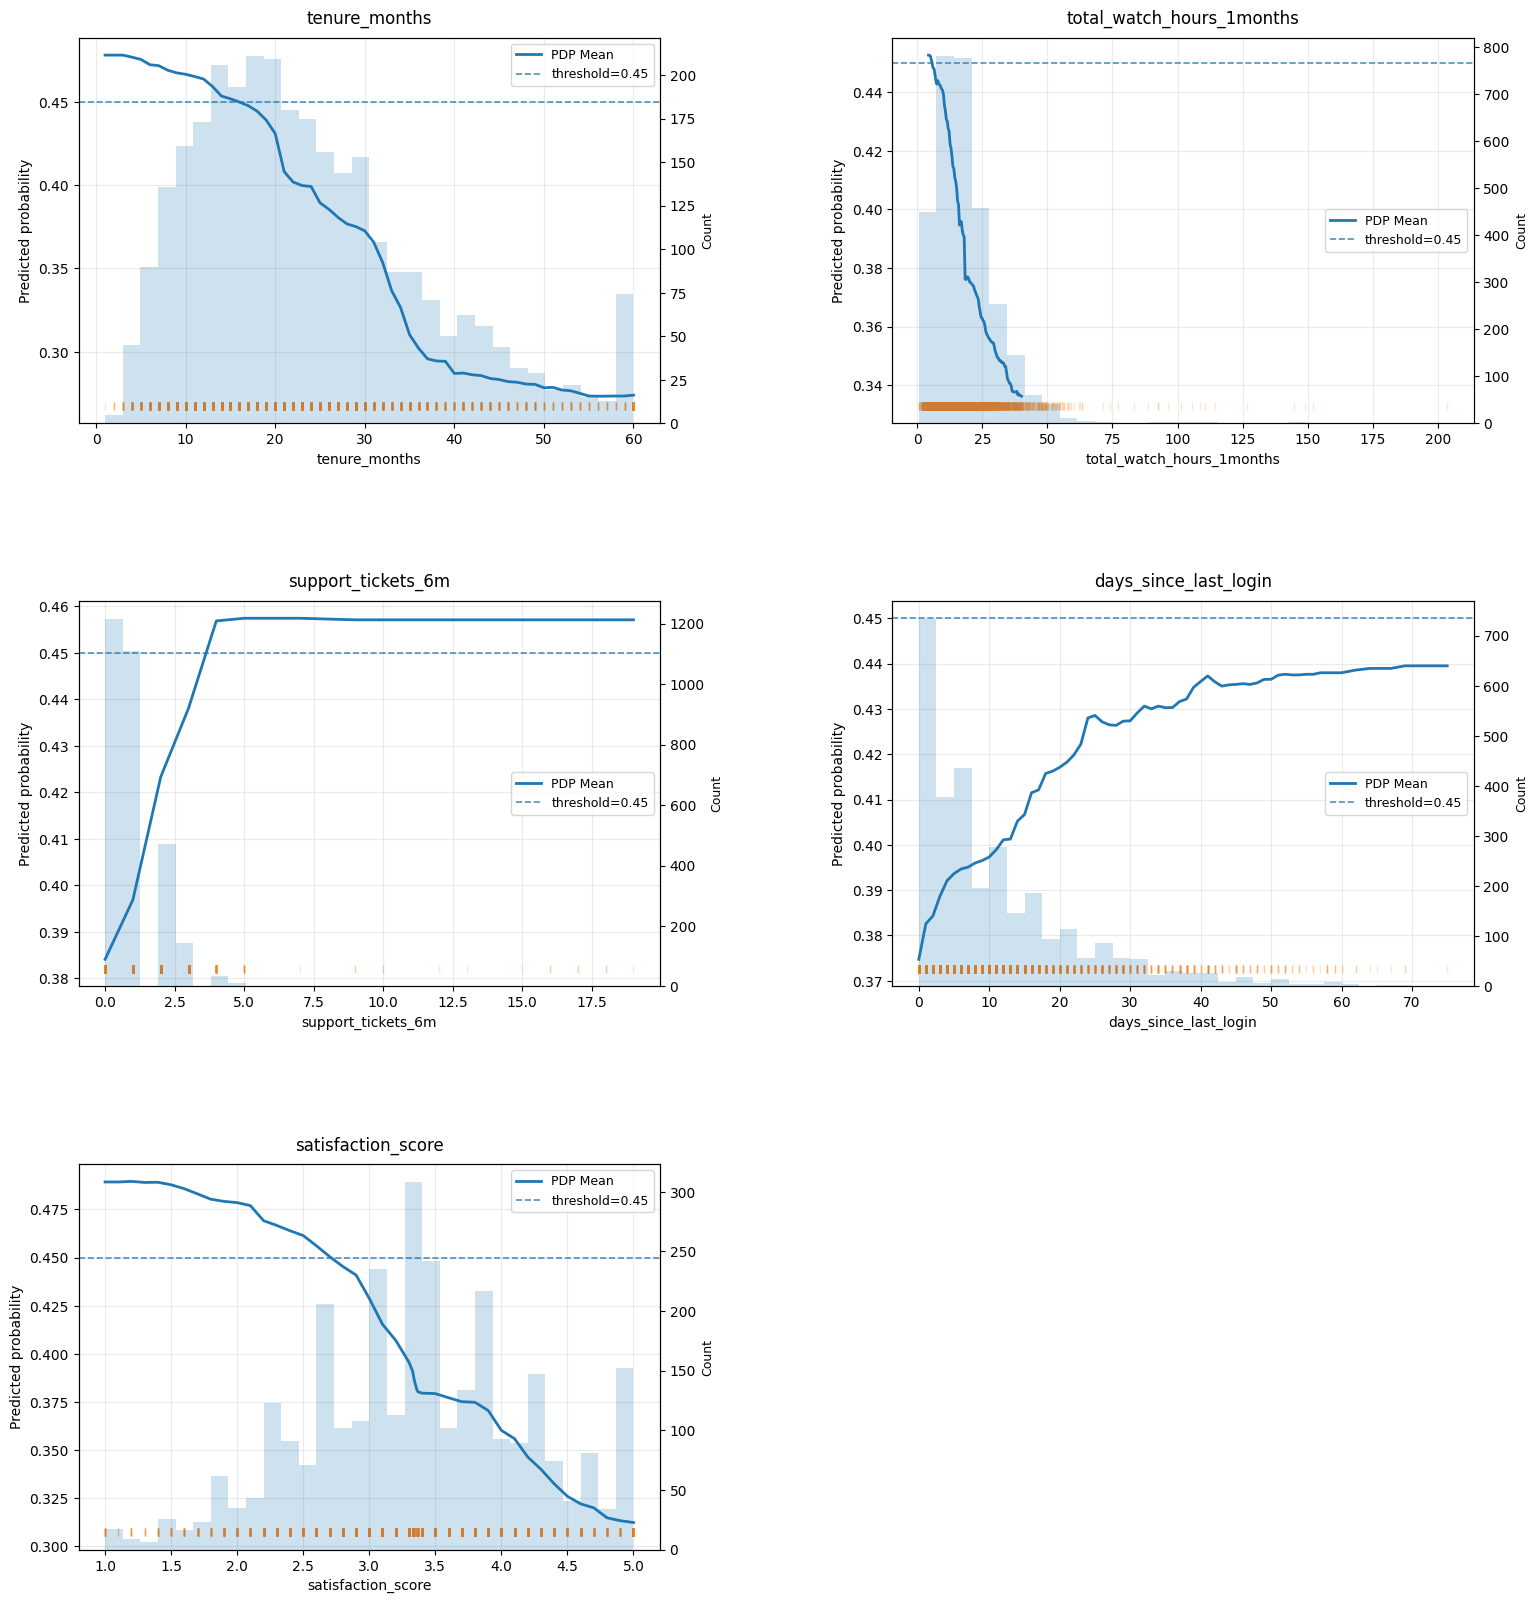

dict_keys(['tenure_months', 'total_watch_hours_1months', 'support_tickets_6m', 'days_since_last_login', 'satisfaction_score'])


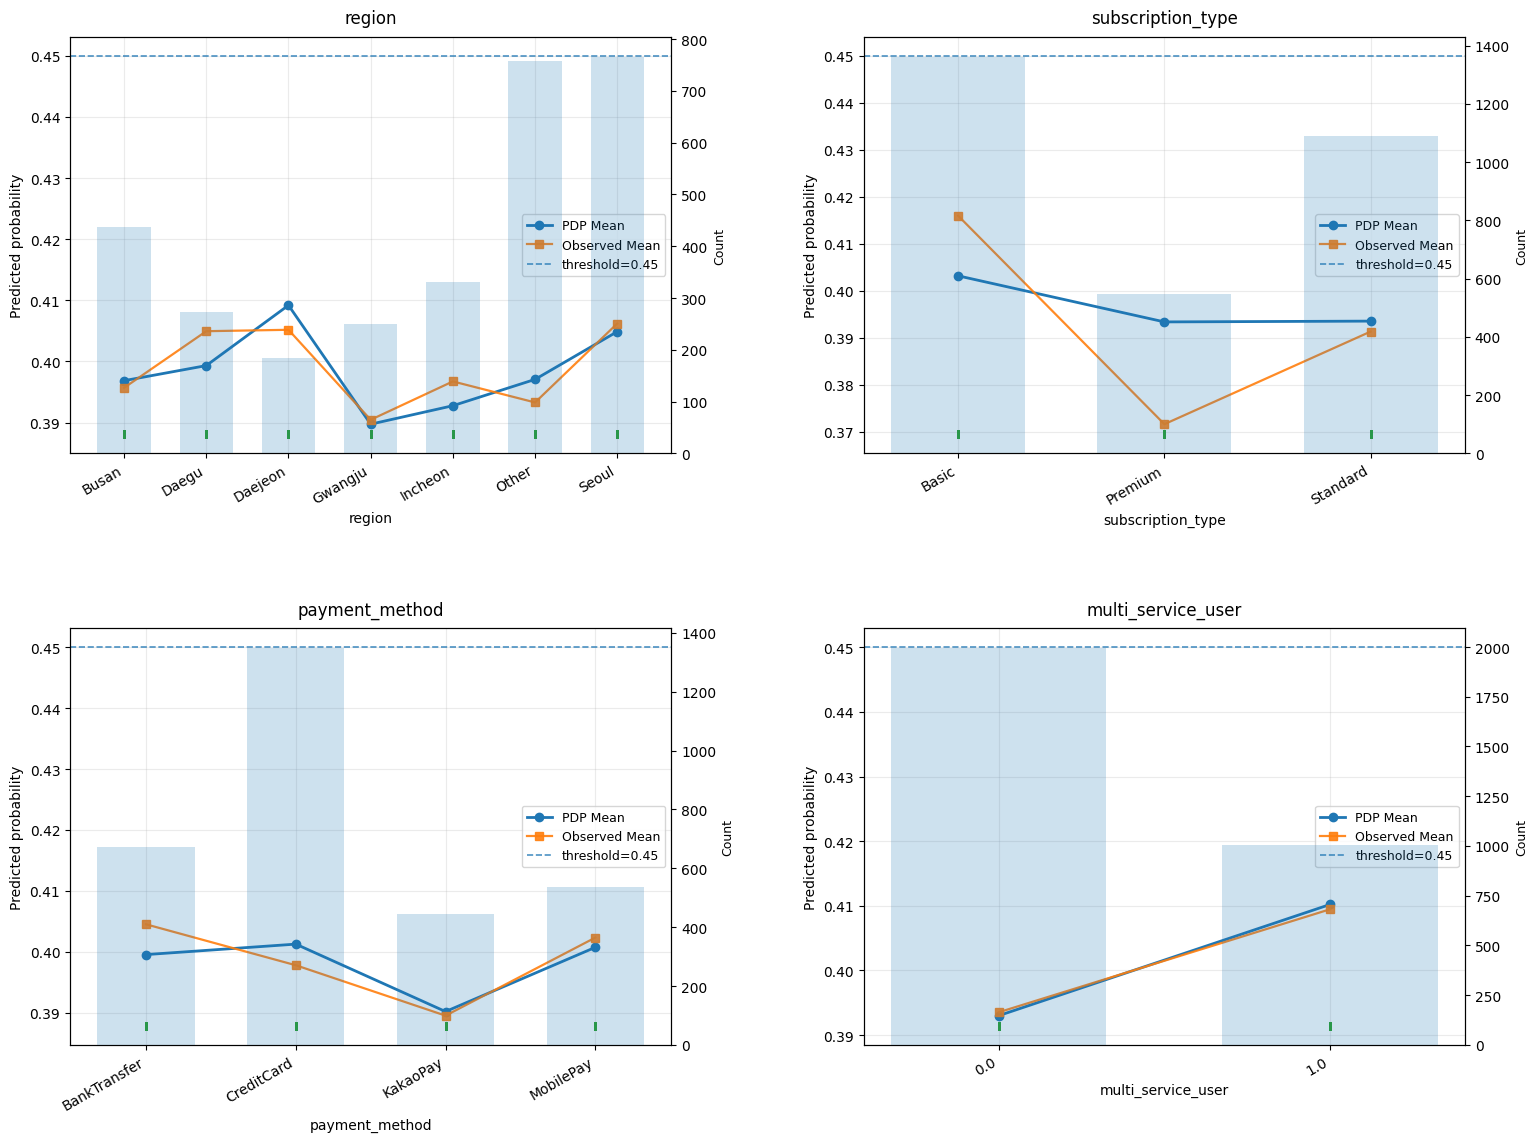

dict_keys(['region', 'subscription_type', 'payment_method', 'multi_service_user'])
['cat__region_Busan', 'cat__region_Daegu', 'cat__region_Daejeon', 'cat__region_Gwangju', 'cat__region_Incheon', 'cat__region_Other', 'cat__region_Seoul', 'cat__subscription_type_Basic', 'cat__subscription_type_Premium', 'cat__subscription_type_Standard', 'cat__payment_method_BankTransfer', 'cat__payment_method_CreditCard', 'cat__payment_method_KakaoPay', 'cat__payment_method_MobilePay', 'remainder__payment_failures_3m', 'remainder__payment_failures_3m', 'remainder__multi_service_user']


In [13]:
#PDP 분석

from function_class import make_numeric_pdp, make_categorical_pdp_group
    #연속적인 수치형 특성 PDP
num_cols = [c for c in test_h.columns.tolist() for col in feat_import_table['p_features'].tolist() if test_h[c].nunique()>=10 and col in c]
num_pdp = make_numeric_pdp(rf, test_h, num_cols, grid_resolution=100, wspace=0.4, hspace=0.46)
print(num_pdp.keys())

    #불연속적 범주형 특성 PDP
from function_class import make_categorical_pdp_group

cat_cols_candid = [c for c in test_h.columns.tolist() for col in feat_import_table['p_features'].tolist() if test_h[c].nunique()<10 and col in c]
cat_cols = []
for col in cat_cols_candid:
    if 'satisfaction_score_na' in col:
        pass
    else:
        cat_cols.append(col)
        
cat_pdp = make_categorical_pdp_group(rf, test_h, cat_cols)
print(cat_pdp.keys())
print(cat_cols)


# 분석 목적 - 분석 원리 및 대상 - 분석 내용 - 해석과 의의 - 한계점 추후 개선안
        #본 분석은 이탈 예측 확률 기여도가 높은 변수 후보군(permutation importance 기준 상위 10개의 변수)에 대해 PDP 분석을 수행, 고객 이탈 확률과 주요 변수 간의 관계 방향 그리고 필요시 급변 구간을 확인하고 이탈 방지 정책의 기준 후보를 도출하는 데에 목적이 있다.
        #PDP의 계산 특성을 고려해 연속적 수치형 변수와 불연속적 범주형 변수를 구분해 비교 검토하였다. 전자의 경우 PDP 평균 곡선과 급변 구간을 점검하여 전역적인 특성 및 관계를 파악하고 고객 군 별 이탈 방지 정책의 기준점을 마련하고자 했다. 또한 표준편차 점검을 통해 평균적 트렌드를 해석함에 있어 신뢰성을 확보하고자 했다.범주형 변수에 대해서는 그룹 내 변수 간 PDP 예측 확률을 비교해 변수의 이탈효과를 파악하고 추가로 실제 집단 평균 예측확률과 비교함으로써 외부효과 가능성을 검토했다.
    
    #연속적 수치형 변수 분석
        #가입기간은 단조감소형으로 18-22개월 및 30-36개월 구간에서 감소폭이 상대적으로 크게 나타나, 초기 리텐션 대응책과 중*장기 전환 구간 관리의 필요성을 시사한다.
        #월총시청시간은 0-20시간 구간에서 가장 큰 감소폭을 보여 저이용고객층을 별도의 특별 관리 고객군으로 클러스터링 하여 시청 및 이용의 활성화 중요성을 확인할 수 있었다.
        #문의건수는 단조증가하는 형태로, 0-3건 구간 동안 확률이 급증하며 3-4 구간 전후에 포화 상태(saturation)를 이루었다. 이는 3건 이후의 고객군을 '불만 누적 유형'으로 이미 이탈 고위험 상태에 있으며 타 고객군과 분리해 별도의 관리책이 필요함을 시사한다. 또한 초기문의건수 구간(0-2) 동안 이탈 확률이 급증한 이후 포화상태를 이루기에, 이탈 방지를 위해서는 고객 문의에 대한 초기 대응이 매우 중요함을 시사하기도 한다.
        #미접속 경과일수의 경우 단조증가형태로 초기미접속(0-10일)에 증가, 중기미접속(10-25) 구간에 큰 폭으로 증가하며 중장기(25-40)부터 기울기가 둔화되었다가 장기(40-) 구간이후 위험이 포화상태에 이름을 확인할 수 있었다. 이로부터 미접속 25일 이후의 고객군은 이미 이탈 위험이 큰 고위험 고객군으로 볼 근거가 있으며 이탈 확률이 급증하는 중기 구간 전후의 고객군과 초기 미접속 고객군에 대한 리텐션 목적의 집중적인 관리 및 액션을 실행할 필요성을 시사한다.
        #만족도는 증가할 수록 평균이탈확률이 감소하는 단조감소형으로 나타났다. 특히 중간 만족도 구간(2-3.3점)의 하락폭이 두드러지며 이외의 구간에서는 하락세가 다소 완만했다. 낮은 만족도 구간은 이미 이탈 고위험 고객군으로 보이며, 만족도가 일정 수준(3.3) 이상일 때 위험도가 낮은 충성 고객으로 분류할 수 있음을 시사한다. 중간 구간의 하락세가 두드러지기에 해당 만족도의 고객 군에 대한 만족도 상승을 위한 대응책이 효과적일 것으로 예상되며, 저만족 고객군에 대해서는 장기적인 만족도 개선 정책이 필요함을 시사한다.
        #종합적으로, 주요 연속적 수치형 변수에 대한 PDP 분석 결과, 각기 다른 급변 구간과 고객군 유형을 보였으며 이에 따라 정책 및 액션의 개입시기, 우선순위도 달리 해야할 것으로 보인다. 
        
    #불연속적 범주형 변수 분석
        #'구독유형'은 그룹 내 변수 간 PDP 평균의 상대적 차이가 뚜렷하게 나타나 정책 우선 검토  변수로 판단되었다. 그 중 Basic 유형은 가장 높은 위험도를, Premium은 낮은 위험도를 보였으나(4%p 차이) 실제 집단 평균은 차이가 상대적으로 완만했다(1%p 차이). 이는 구독유형 변수 효과 외에 실제 집단의 구성 분포의 영향으로 위험도를 약화시켰을 가능성을 시사한다. 따라서 구독 유형을 별도의 타깃 정책 변수로 다루기 위해서는 다른 주요 변수와의 결합 분석을 통해 타깃을 보다 세분화 하여 검토할 필요가 있다.
        # 반면, '지역'과 '결제방식'은 그룹 내 PDP의 상대적인 차이는 있었으나(각각 대전, 신용카드/모바일페이 위험도 높음) 그 정도가 작아(1%p 내외) 타깃 정책 후보 변수로 활용하기엔 제한적이다. 따라서 세그먼트 세분화 또는 결제 관련 이슈 검토를 위한 보조 변수 역할로 활용하는 것이 좋다.
        # '멀티서비스유저'의 경우 사용자가 비사용자에 비해 약 2%p 높은 위험도를 보였다. 이는 멀티 서비스 유저에 대한 별도의 타겟 정책을 설정할 근거가 있음을 시사하며, 예로 핵심 서비스에 대한 로열티 및 혜택 강화 정책을 고려해볼 수 있다. 또한 PDP 확률과 실제예측확률 차이가 매우 작아(0.1%p 내외), 변수 자체 효과에 대한 비교적 명확한 해석이 가능했다.
          

In [14]:
   #SHAP
import shap
explainer = shap.Explainer(rf, test_h) #해당 객체가 shap값 계산
shap_exp = explainer(test_h) # 결과 담은 객체 생성

def get_positive_class_explanation(shap_exp): 
   vals = shap_exp.values
   
   if vals.ndim == 3 and vals.shape[-1] == 2:
      return shap_exp[:, :, 1]
   
   return shap_exp

shap_exp_pos = get_positive_class_explanation(shap_exp)

100%|===================| 5996/6000 [09:31<00:00]        

,mean_abs_shap,mean_shap,std_shap,feature_type
tenure_months,0.05502,-0.00683,0.06598,numeric
satisfaction_score,0.04371,-0.00180,0.05094,numeric
total_watch_hours_1months,0.03492,0.00319,0.03994,numeric
price_increase_recent,0.01810,-0.00051,0.02083,numeric
payment_failures_3m,0.01589,-0.00099,0.01750,numeric
support_tickets_6m,0.01347,0.00092,0.01868,numeric
days_since_last_login,0.01340,0.00207,0.01753,numeric
multi_service_user,0.00817,-0.00073,0.00875,numeric
monthly_fee,0.00790,-0.00026,0.00923,numeric
auto_renew,0.00674,-0.00075,0.00710,numeric


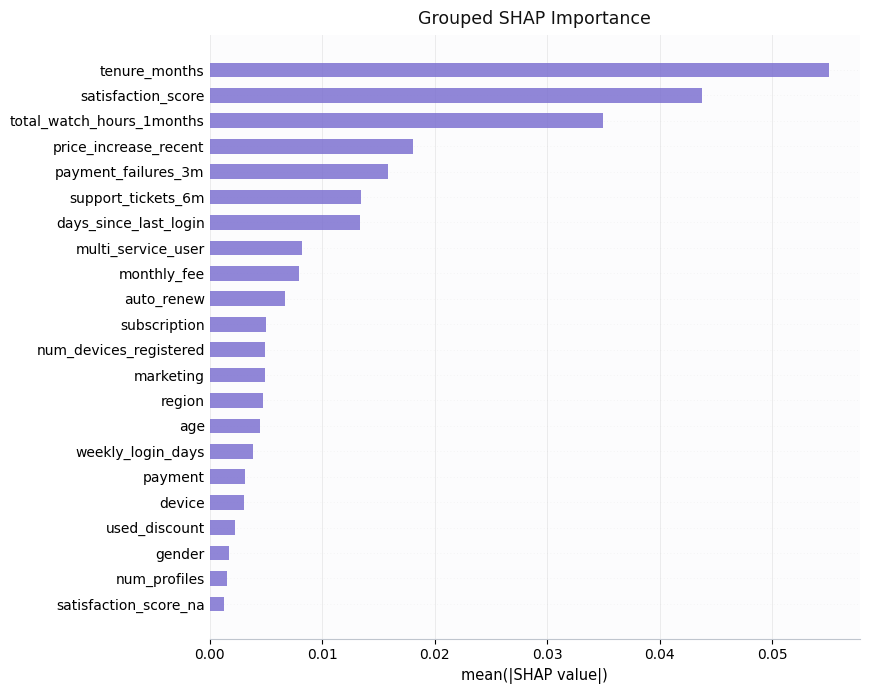

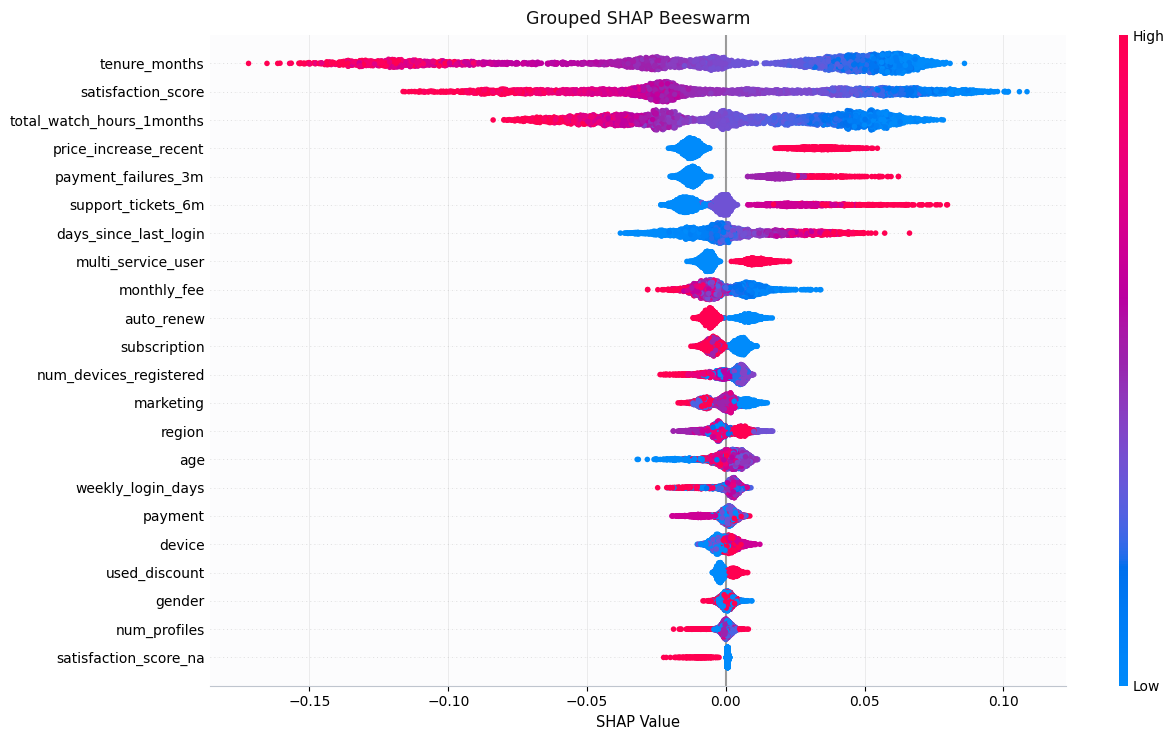

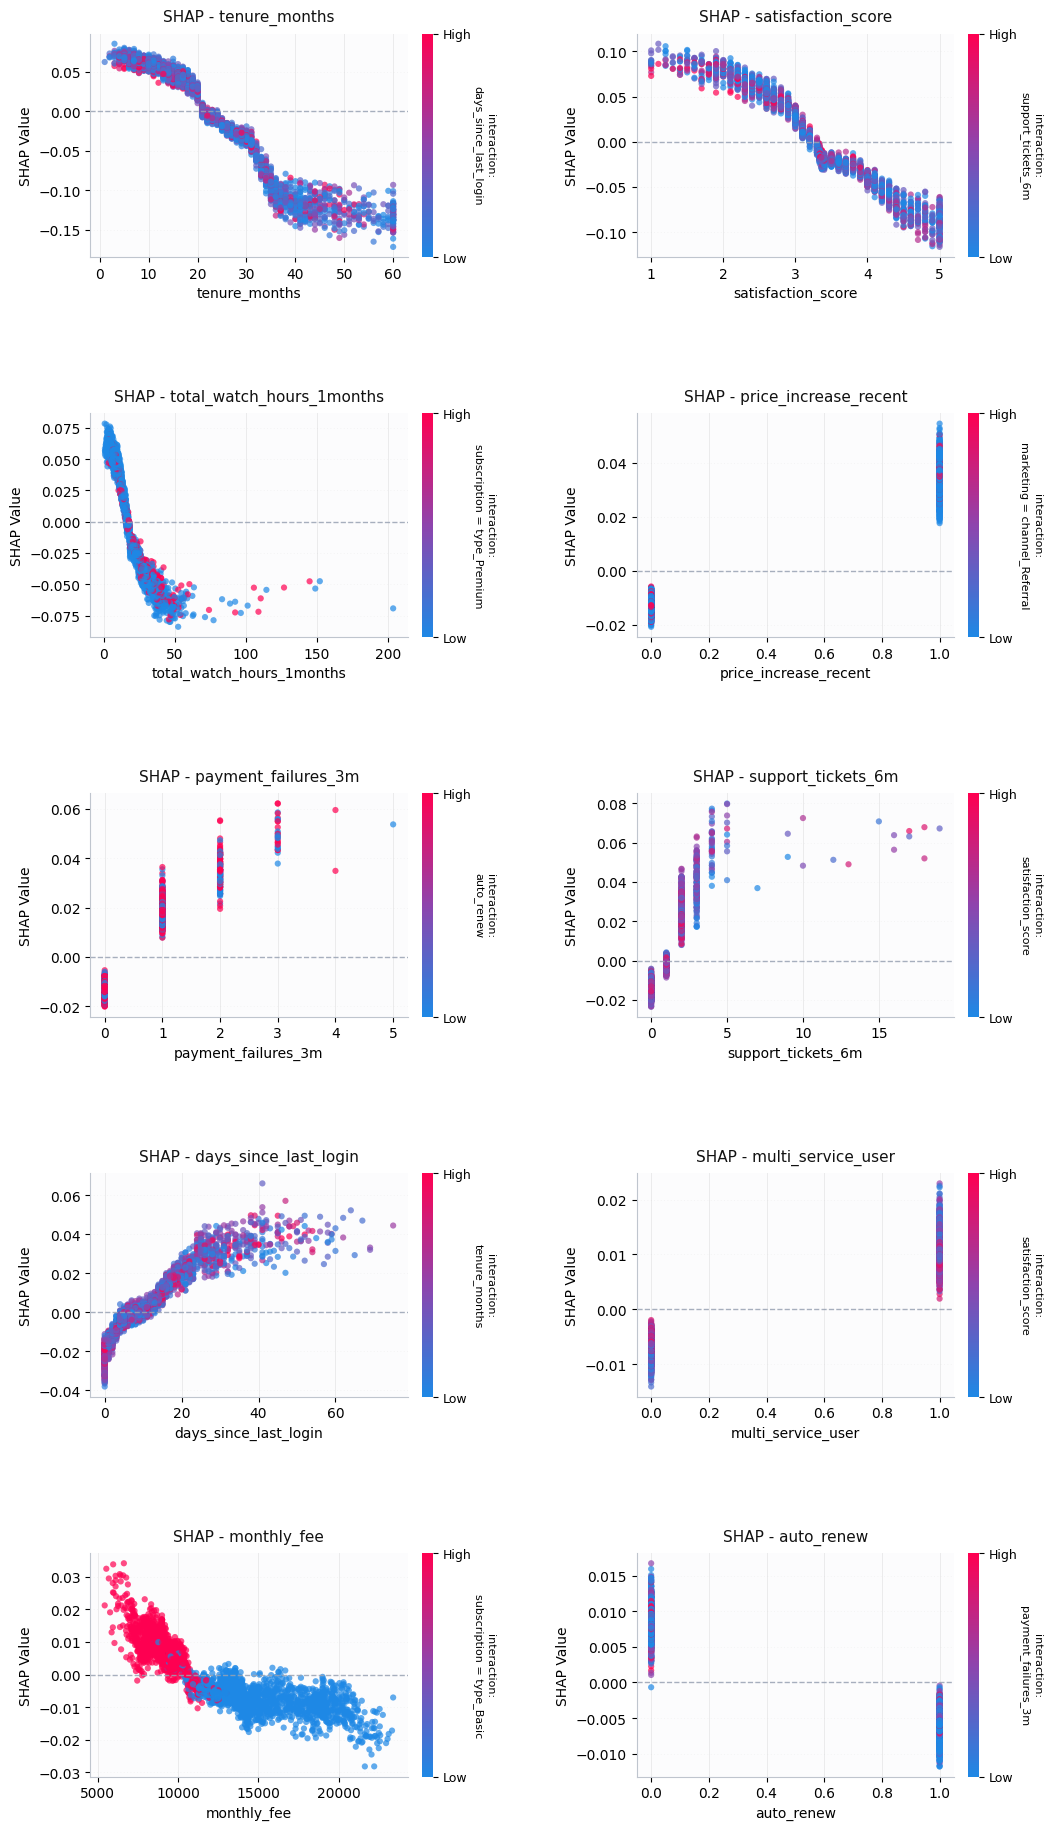

In [19]:
#SHAP 분석
from function_class import plot_shap_global

gl_shap = plot_shap_global(test_h, shap_exp_pos.values, max_display=50, beeswarm_plot_size= (13, 7.5))

from function_class import plot_shap_dependence
dep_col = gl_shap['top_features'][:10]
pl_shap = plot_shap_dependence(test_h, shap_exp_pos.values, feature = dep_col, title_prefix="SHAP", n_cols=2)


# 목적:
# 모델의 변수 별 이탈 예측 확률 기여도를 확인하고, PDP 정책 기준선과의 정합성 여부, 타 변수와의 상호작용 가능성을 검토하기 위해 SHAP 분석을 진행했다.
# 이를 통해 정책의 우선순위, 실행종류, 운영방식을 정교화하고 타깃 세그먼트를 보다 세분화할 수 있는 합리적 근거를 마련할 수 있을 것으로 기대한다.

    #전역적 특성 분석 결과
# 먼저, 모델의 예측확률 기여도와 선형성 정도를 를 파악하기 위해 전역 중요도표, Beeswarm 시각 자료를 활용했다.
# SHAP 전역 분석 결과, 가입기간, 만족도 총 시청시간이 평균 절댓값 기준 가장 높은 전역 중요도를 보여 모델 예측 확률에 가장 크게 기여하는 핵심 변수로 확인되었다.
# 그 다음으로는 가격인상, 결제실패, 문의건수, 로그인 경과일수 등이 뒤를 이었는데, 일부 변수(가격인상, 결제실패 등)는 permutation importance 대비 상대적으로 높은 우선순위를 보였다. 이는 두 기여도 계산 대상이 다르기 때문으로, 해당 변수들이 모델의 확률 예측에는 주요하게 관여하나 독립적인 성능 기여 정도는 낮을 가능성을 시사한다.
# 또한 상위 변수들은 공통적으로 SHAP 표준편차가 비교적 크게 나타나, 고객별 기여도 이질성이 존재할 가능성을 시사한다. 이는 변수 간 상호작용, 비선형성, 세그먼트 차이의 가능성을 포함하므로 dependence plot을 통해 추가 검토할 필요가 있다.
# 전반적인 변수-타깃 관계는 PDP 분석 결과와 크게 다르지 않았으며, 방향성 또한 일관되게 나타났다. 다만, age는 일부 구간(저연령-중연령)에서 방향성이 혼재되는 모습이 관찰되어 추가 검토가 필요한 것으로 판단된다.

    #SHAP dependence plot 분석 결과
# SHAP dependence 분석은 전역 중요도 상위 변수들을 대상으로 수행하였으며, 각 변수의 이탈 예측 기여 방향, 기여 전환구간, 고객별 편차, 상호작용 가능성을 검토하는 데 목적이 있다. 분석 결과, 가입기간, 만족도, 총 시청시간은 전반적으로 이탈 예측을 낮추는 방향의 기여를 보였고, 가격 인상, 결제 실패, 고객문의, 로그인 경과일수는 이탈 예측을 높이는 방향의 기여를 보였다.
# 가입기간은 전반적으로 음(-)의 기여를 보였으며, 약 20개월 전후와 30개월 전후에서 하락 기여가 확대되는 구간이 관찰되었다. 특히 30개월 이후에는 음의 기여가 유지되면서도 고객 간 편차가 확대되어, 장기 가입자군 내부의 이질성이 커지는 양상이 나타났다. 이에 따라 PDP에서 도출한 가입기간 기준선은 유지하되, 중장기 가입 고객군에 대해서는 추가적인 세그먼트 검토가 필요하다.
# 만족도 점수는 단조감소형 기여를 보였고, 약 2.7~3.3 구간에서 하락 기여가 확대되며 3.3 전후에서 SHAP 값이 0 부근을 지나 음의 기여가 뚜렷해졌다. 또한 저만족·고만족 극단 구간에서는 고객 간 편차가 상대적으로 크게 나타나, 만족도 단독보다 다른 특성과의 결합 효과를 함께 검토할 필요가 있다.
# 총 시청시간은 강한 음의 기여를 보였으며, 약 15~16시간 전후에서 기여 방향 전환이 나타났고 20시간 전후까지 하락 기여가 가장 빠르게 확대되었다. 이후에는 음의 기여가 유지되지만 증가 폭은 둔화되고 고객 간 편차도 확대되어, 저시청층과 고시청층을 구분한 추가 검토가 필요하다. 다만 50시간 이상 구간은 표본 수가 적어 과도한 해석은 지양하였다.
# 가격 인상 변수는 연속적 관계보다는 이진형 분리효과가 매우 뚜렷하게 나타났다. 가격 인상 경험이 있는 집단은 일관되게 양(+)의 SHAP 값을 보여 이탈 예측을 높이는 방향으로 기여했고, 미경험 집단은 반대로 음(-)의 기여를 보였다. 또한 가격 인상 경험 집단 내부의 편차가 더 크게 나타나, 가격 인상 이후 고객별 반응 차이를 만드는 추가 변수 검토가 필요하다.
# 결제 실패는 무건과 유건 집단 사이의 분리효과가 비교적 뚜렷하게 나타났으며, 실패 건수가 증가할수록 이탈 예측 기여가 커지는 경향을 보였다. 다만 3건 이상 구간은 표본 수가 적어 신중한 해석이 필요하다. 유건 집단 내부에서는 고객 간 편차가 상대적으로 크게 나타나, 단순 건수 구분보다 유건 집단 내 세분화가 후속 과제로 판단된다.
# 고객문의 역시 0건과 유건 집단 간 분리효과가 크게 나타났으며, 2건 이후부터 양(+)의 기여가 보다 뚜렷하게 확인되었다. 다만 고건수 구간은 표본 수가 적고, 유건 집단 내부의 편차도 커서 반복 문의 고객군에 대한 추가 세분화가 필요하다.
# 로그인 경과일수는 전반적으로 단조증가형 기여를 보였고, 약 7일 전후에서 기여 방향 전환이 뚜렷하게 나타났다. 이후 25일 전후까지는 양(+)의 기여가 확대되는 경향을 보였으며, 25일 이후에는 고객 간 편차가 더욱 커져 장기 미접속 고객군 내부의 이질성이 증가하는 양상이 확인되었다. 이에 따라 약 7일 전후 구간은 초기 재접속 유도 기준 후보로 해석할 수 있다.
# 종합하면, SHAP dependence 분석은 PDP에서 확인한 주요 방향성과 대체로 일관된 결과를 보였으며, 동시에 일부 변수에서는 고객군별 편차 확대와 이질성이 관찰되었다. 이는 향후 정책 기준선 자체를 크게 수정하기보다는, 기존 PDP 기준선을 유지한 상태에서 특정 구간 또는 집단 내부를 추가로 세분화해 운영할 필요가 있음을 시사한다.

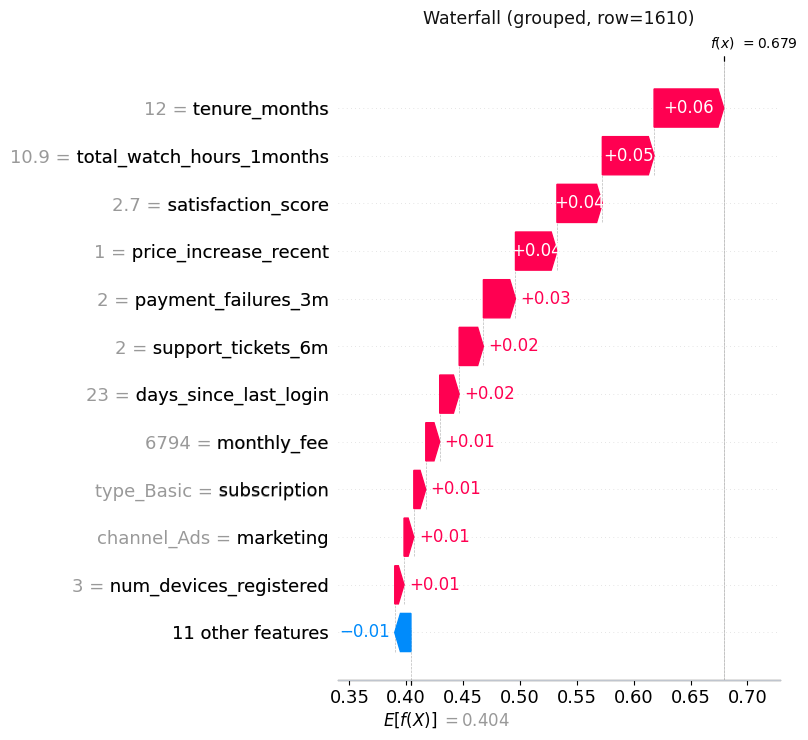

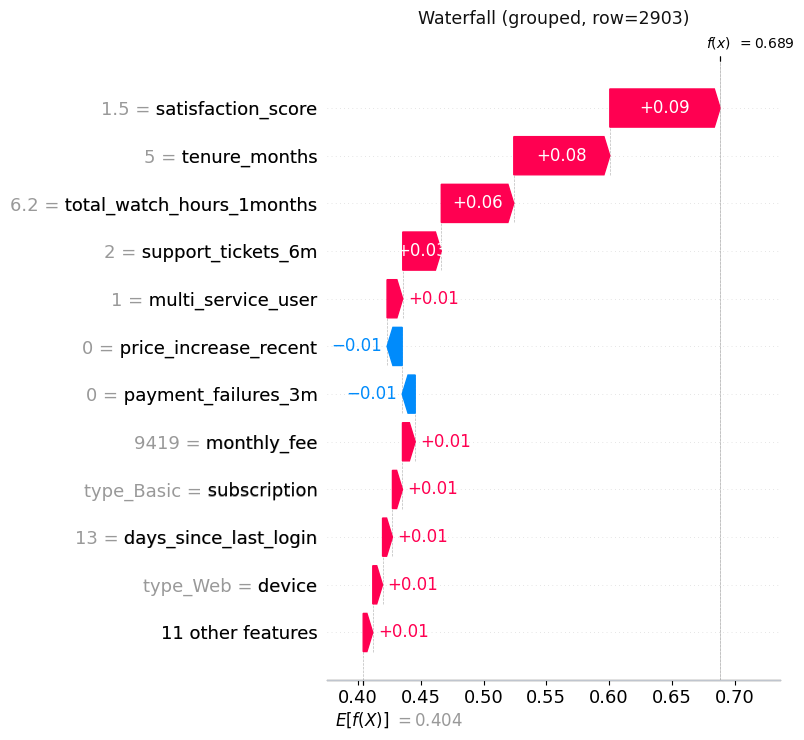

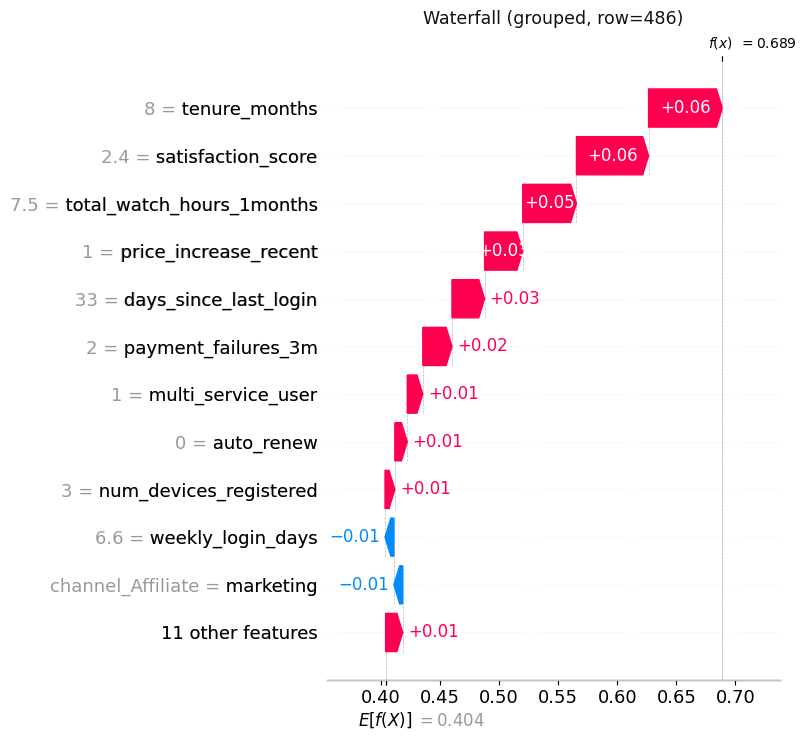

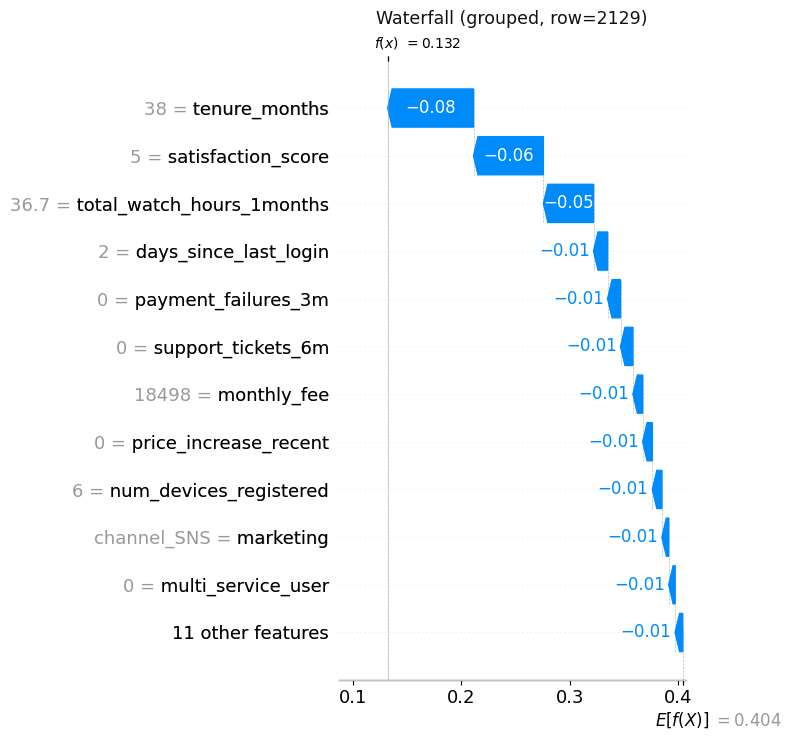

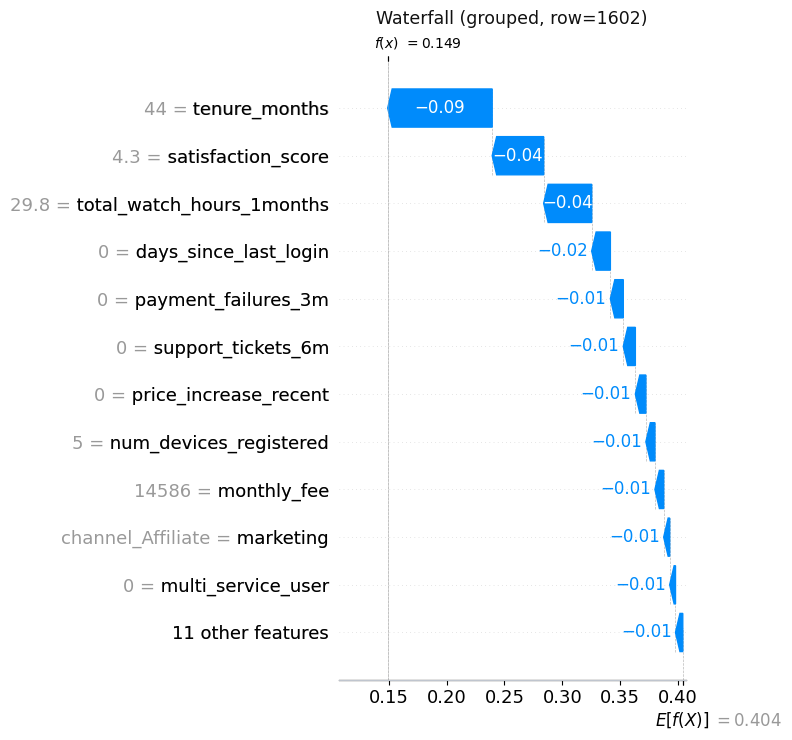

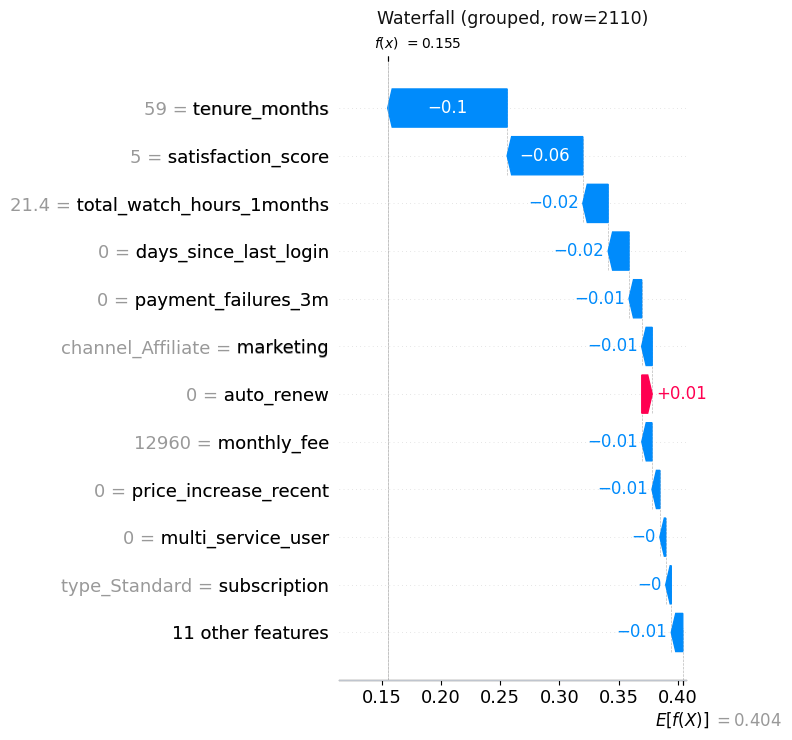

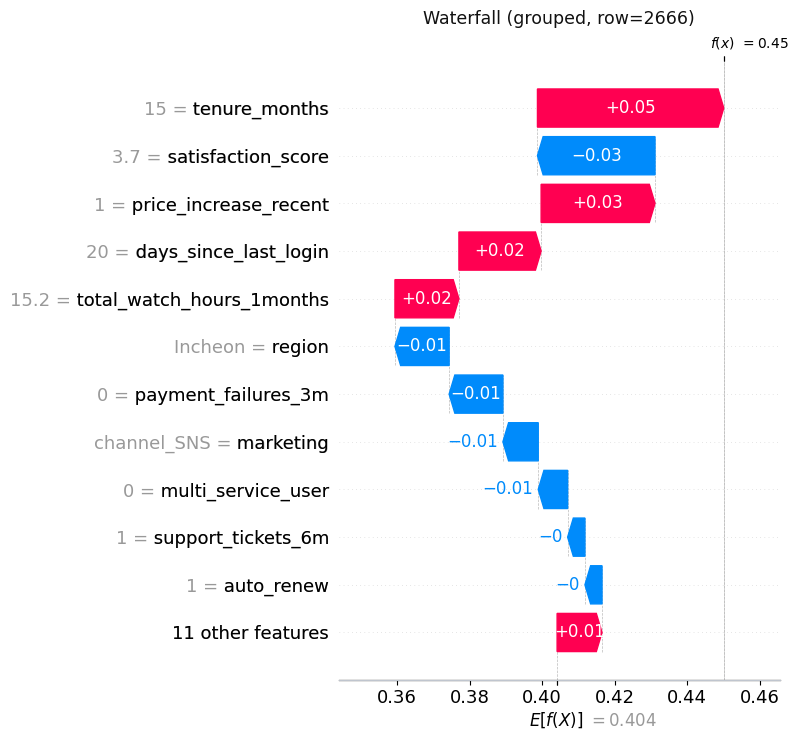

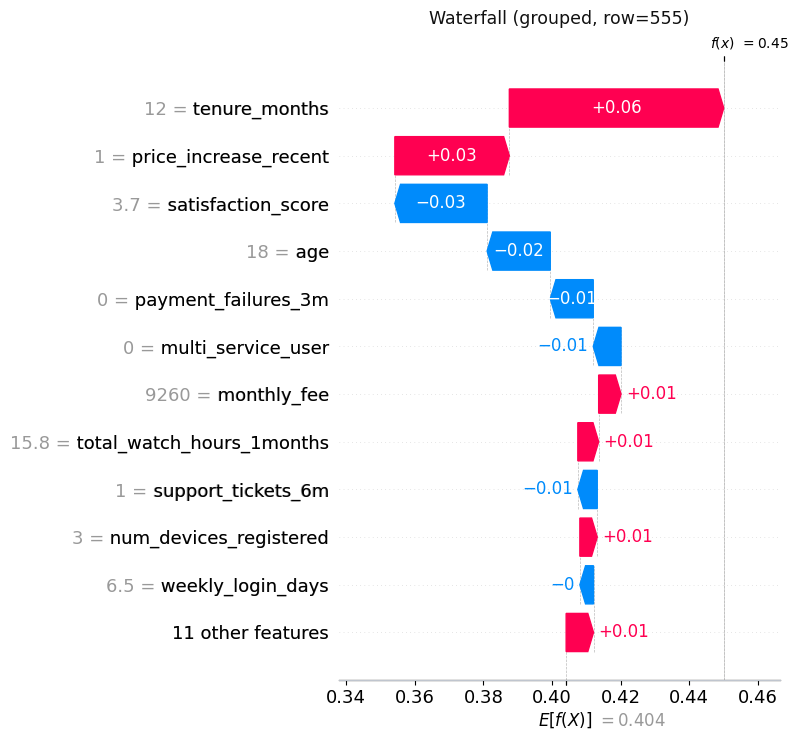

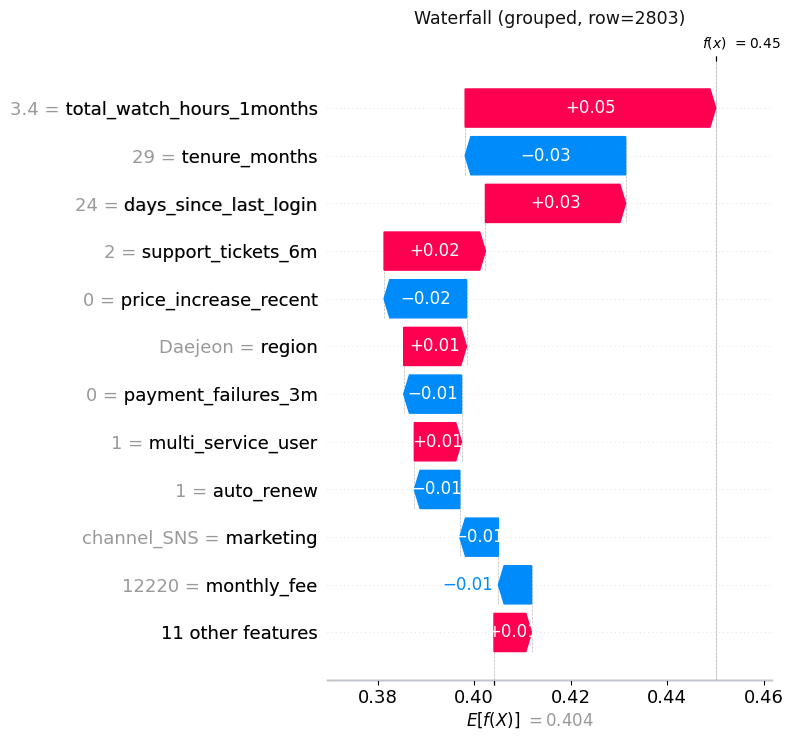

In [ ]:
from function_class import plot_shap_waterfall
import shap


pred_proba = rf.predict_proba(test_h)[:, 1]

top3_prob = np.argsort(pred_proba)[-3:]
bot3_prob = np.argsort(pred_proba)[:3]
thres_prob = np.argsort(np.abs(pred_proba - 0.45))[:3]

for cus in top3_prob:
    result = plot_shap_waterfall(test_h, shap_exp_pos.values, shap_exp_pos.base_values[int(cus)], row=int(cus))
    result['waterfall_table']
    
for cus in bot3_prob:
    result = plot_shap_waterfall(test_h, shap_exp_pos.values, shap_exp_pos.base_values[int(cus)], row=int(cus))
    result['waterfall_table']
    
    
for cus in thres_prob:
    result = plot_shap_waterfall(test_h, shap_exp_pos.values, shap_exp_pos.base_values[int(cus)], row=int(cus))
    result['waterfall_table']


In [ ]:
#로지스틱 회귀 모델: 성능과 계수 비교

print(train_i.shape, valid_i.shape, test_i.shape)

#1. 셋 나누기 2. 범주형/수치형 구별 3. 범주형 원핫인코더(로지스틱은 숫자형만 받음), 4.셋 칼럼 맞추기 5. 수치형 스케일링 

# 로지스틱 회귀 분류 모델 설계의 목적
    # 랜덤포레스트 모델은 복잡한 패턴의 데이터에 대해 예측 성능이 좋으며 SHAP 분석을 통해 세분화된 정책 및 세그먼트 별 액션 설계가 가능하다는 장점이 있다. 하지만 모델이 복잡하여 예측 설명력에 한계가 있다는 단점 역시 존재한다.
    # 로지스틱 회귀 분류의 경우 데이터의 패턴이 선형적이라는 전제 하에 수행되므로 데이터 패턴을 단순화 시켜버리는 단점이 있지만, 변수 해석이 비교적 명확하고 용이하다는 장점이 있다.
    # 본 분석에는 1차적으로 로지스틱 회귀 분류 모델을 변수 해석의 목적으로 이용하되, 성능에 있어 랜덤포레스트 모델과 현격한 차이가 나지 않을 경우 제한적으로 운영 목적으로 사용할 수 있을 것이라 예상한다.  
    # 따라서 동일 데이터에 대해 로지스틱 회귀 분류 분석을 수행하여 랜덤포레스트 모델과 성능 및 변수 관계를 비교 해석하였다. 

# 훈련, 검증, 테스트 데이터 준비
    # 로지스틱 회귀 모델은 랜덤포레스트와 마찬가지로 수치형 데이터만 입력 받기 떄문에 범주형 변수는 따로 원핫인코딩 처리하였다.
    # 반면, 회귀모델식 계산 특성상 데이터의 단위에 민감하게 영향받기 때문에 수치형 변수에 대해서는 별도의 스케일링 처리를 하여 단위가 큰 변수에 의해 결과가 왜곡되는 상황을 최소화 하고자 했다.

cat_cols = train_i.select_dtypes(include='object').columns.tolist()
num_cols = train_i.select_dtypes(exclude='object').columns.tolist()

train_lh = pd.get_dummies(train_i, columns=cat_cols, drop_first=True)
valid_lh = pd.get_dummies(valid_i, columns=cat_cols, drop_first=True)
test_lh = pd.get_dummies(test_i, columns=cat_cols, drop_first=True) #drop_first는 더미 변수 가운데 한 범주를 기준 범주로 두는 것.


valid_lh = valid_lh.reindex(columns=train_lh.columns, fill_value=0)
test_lh = test_lh.reindex(columns=train_lh.columns, fill_value=0)

print(f"데이터 형태 확인: {train_lh.shape, valid_lh.shape, test_lh.shape}")
print((train_lh.columns == valid_lh.columns).all())
print((train_lh.columns == test_lh.columns).all())

from sklearn.preprocessing import StandardScaler
ss = StandardScaler()

train_s = ss.fit_transform(train_lh)
valid_s = ss.transform(valid_lh)
test_s = ss.transform(test_lh)

#로지스틱 모델 학습
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter = 500, class_weight='balanced', random_state=42)
lr.fit(train_s, train_t)

#로지스틱 모델 검증
from function_class import evaluate_binary_classifier
eval = evaluate_binary_classifier(lr, valid_s, valid_t, 'valid')

    # 원핫인코더와 스케일링 처리한 학습데이터를 로지스틱 회귀 분류 모델에 학습(파라미터 기본값), 검증데이터 셋을 통해 roc-auc, accuracy, precision, recall, f1 등의 척도를 활용해 모델의 성능을 검증하였다.
    # 성능 분석 결과, roc-auc는 0.7355로 타깃인 이탈 집단에 73%의 더 높은 위험도를 부여하고 있었으며 랜덤포레스트(0.7317)보다 소폭 높은 분류 성능을 보여주었다. 랜덤포레스트 모델과 비교했을 때 유의미한 차이는 보이지 않았으나, 클래스에 대한 기본적인 판별력은 확보한 것으로 해석할 수 있다.
    # 또한 threshold=0.5 기준 recall에서 좋은 성능을 비교적 큰 격차로 보여주어 랜덤포레스트 분류 모델 보다 실제 이탈 고객 포착에 있어 뛰어난 성능을 가진 것으로 확인되었다. 
    # 다만, f1 = 0.278, precision=0.1744로 오탐 비율과 클래스간 불균형 성능에 있어서는 상대적으로 더 취약했다.
    # 모델 운영 관점에서, 두 모델은 장단점이 뚜렷하게 병존하는 모델로 보여지며, 실제 이탈 고객을 많이 포착하는 데에 목적이 있다면 로지스틱 회귀 분류 모델이 유리할 수 있으나, 광범위하게 분류하는 특징이 있어 오탐 비용이 커질 수 있다는 한계 역시 고려하는 것이 타당하다
    # 세부적인 성능은 높은 roc-auc로 추후 하이퍼파라미터 튜닝, threshold 조정으로 개선될 여지가 있기에 추가적인 튜닝과 조정 후 결과를 확인할 필요가 있다.

# [Score Summary]
# ==================================================
# accuracy : 0.6667 / 
# precision: 0.1744 / 0.22(rf)
# recall   : 0.6844 / 0.42(rf)
# f1-score : 0.2780 / 0.29(rf)
# roc-auc  : 0.7355 / 0.7317(rf)



# 로지스틱 모델 하이퍼 파라미터 튜닝
    # 기본 파리미터에서 발생한 문제들(높은 오탐율, 클래스 분류간 극심한 불균형)을 완화하고자 GridSearch를 통해 하이퍼파라미터 튜닝을 수행하였다.
    # 오탐 불균형을 해소하고 실제 이탈 고객 포착이 분류의 주된 목적임을 고려해, refit='f1'로 설정 후 타깃/비타깃 집단 분류 성능의 불균형을 해소하고자 했다.
    # 튜닝 결과 최적 파라미터 조합은  {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 300, 'penalty': 'l2', 'solver': 'lbfgs'}로 확인 되었으며,
    # 동일한 검증 셋으로  테스트 결과 threshold = 0.5 기준, precision=0.1733, recall = 0.68, f1=0.2762로 나타나 기본 설정값의 성능에서 소폭 하락한 양상을 보였다.
    # 따라서 튜닝 전후 f1 및 recall, precision score가 유사하게 나타나 본 데이터에서 기본 로지스틱 회귀 파라미터가 비교적 안정적인 기준 모델로 작동한 것으로 판단된다.
    # 다만, 적정 임곗값은 모델 별로 다를 수 있으므로 튜닝 설정한 모델에 대해 threshold 조정을 통한 성능의 제고를 기대해볼 수 있다.
    
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV, GridSearchCV

splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_dist = {
    'C': [0.01, 0.1, 1, 5, 10, 50],
    'penalty': ['l2'],
    'class_weight': [None, 'balanced'],
    'solver': ['liblinear', 'lbfgs', 'saga'],
    'max_iter': [300, 500, 1000]
}

scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

rs_lr = GridSearchCV(estimator=lr, param_grid= param_dist, scoring=scoring, 
                        refit='f1', cv=splitter, return_train_score=True, verbose=0)
rs_lr.fit(train_s, train_t)

print(f"최적 파라미터: {rs_lr.best_params_}")
print(f"최고 f1 스코어: {rs_lr.best_score_}")

result_df = pd.DataFrame(rs_lr.cv_results_)
cols = [
    'params',
    'mean_test_accuracy',
    'mean_test_precision',
    'mean_test_recall',
    'mean_test_f1',
    'mean_test_roc_auc',
    'rank_test_f1'
]

lr2 = rs_lr.best_estimator_
evaluate_binary_classifier(lr2, valid_s, valid_t, "valid")


from function_class import make_threshold_table

thres_result = make_threshold_table(lr2, valid_s, valid_t, 'valid')
thres_result

    # threshold 조정
    # 본 분석에서는 랜덤 포레스트와 동일한 threshold 조정 기준을 적용해, f1-score가 최대가 되는 기준 값을 선정하였다.
    # 랜덤포레스트와 달리 threshold=0.65일 때 f1이 최개다 되며(0.3186) 이떄의 recall=0.4311, precision=0.2526로 랜덤포레스트에 비해 f1과 precision은 높았으나 recall 성능은 낮았다.
    # 따라서 로지스틱 회귀 분류는 랜덤포레스트에 비해 실제 이탈 집단을 포착하는 데에 있어서는 성능이 아쉽지만, 비이탈 집단에 대한 성능 척도와 클래스간 균형이 좋다는 점에서 비용 측면의 효율성을 제고할 수 있는 모델이다.

logistic_eval = evaluate_binary_classifier(lr2, test_s, test_t, 'test', threshold=0.65)
    # 최종 성능 평가
    # threshold=0.65 기준에서, 테스트 세트를 통한 최종 성능을 확인한 결과,
    # accuracy 0.82, precision 0.21, recall 0.35, f1 0.27로 랜덤포레스트 모델에 비해 이탈 집단의 오탐 비율은 낮았으나, 실제 이탈 고객을 포착하는 데에는 한계가 있었다. 
    # 결론적으로, 로지스틱 회귀 모델은 precision과 recall 사이의 trade-off가 존재했으며 불균형 완화를 위해 threshold를 0.65로 조정한 최종 모델은 precision과 정확도 측면에서 개선되었으나 recall이 낮아져 실제 이탈 고객을 놓칠 가능성이 커졌다.
    # 따라서 비용 효율성을 우선순위로 했을 떄에는 부분적으로 활용 가능하나, 이탈 탐지 우선 전략에 있어서는 랜덤 포레스트 모델 위주의 운영이 타당해 보인다.
    


log_table = pd.DataFrame({'feature': train_lh.columns, 'coef': lr2.coef_[0], 'abs_coef': np.abs(lr2.coef_[0])})

log_table['odds_ratio'] = np.exp(log_table['coef'])

log_table.sort_values(by='abs_coef', ascending=False).head(10)

# 변수해석
    # 회귀 변수와 이탈행동 간의 관계를 분석하기 위해 회귀 계수를 상세 검토했고, coef 절댓값 기준 상위 10개의 변수에 대해 계수 부호(coef)와 오즈비를 함께 확인하였다.
    # 분석 결과, [가입기간, 만족도, 총시청시간, 자동결제]는 이탈 위험 감소 방향으로, [가격인상, 결제실패, 고객문의, 비로그인 경과일수, 다중서비스이용]은 이탈 위험 증가 방향으로 나타났다. 랜덤포레스트 PDP, SHAP 분석 결과와 일관된 방향성을 보였다.
    # 가입기간, 만족도, 총시청시간은 두 모델에서 공통적으로 이탈 및 예측에 기여하는 주요 변수로 확인되었기에 이탈 방지를 위한 핵심 관리 지표로 해석할 수 있다.
    # 다만, 만족도의 경우 실행 가능성이 곤란한 점이 존재하기에 가입기간과 총 시청시간 행동을 주요 관리 후보군으로 설정, PDP 정책 기준선과 SHAP 세그먼트 분할 기준을 바탕으로 시기*고객 별 대응 책을 마련하는 것이 타당해보인다.
    
#     	feature	coef	abs_coef	odds_ratio
# 1	tenure_months	-0.504354	0.504354	0.603895
# 14	satisfaction_score	-0.427800	0.427800	0.651942
# 3	total_watch_hours_1months	-0.283758	0.283758	0.752949
# 12	price_increase_recent	0.267833	0.267833	1.307129
# 8	payment_failures_3m	0.234768	0.234768	1.264615
# 7	support_tickets_6m	0.197536	0.197536	1.218397
# 9	days_since_last_login	0.179308	0.179308	1.196389
# 13	multi_service_user	0.147529	0.147529	1.158967
# 11	auto_renew	-0.113655	0.113655	0.892566
# 31	marketing_channel_Affiliate	-0.105317	0.105317	0.900039



(9600, 22) (2400, 22) (3000, 22)
데이터 형태 확인: ((9600, 35), (2400, 35), (3000, 35))
True
True
[valid Model Evaluation]
threshold: 0.5
--------------------------------------------------
    data  threshold  accuracy  precision_1  recall_1   f1_1  roc_auc
0  valid        0.5    0.6667       0.1744    0.6844  0.278   0.7355

[Confusion Matrix]
[[1446  729]
 [  71  154]]

[Classification Report]
              precision    recall  f1-score   support

           0       0.95      0.66      0.78      2175
           1       0.17      0.68      0.28       225

    accuracy                           0.67      2400
   macro avg       0.56      0.67      0.53      2400
weighted avg       0.88      0.67      0.74      2400


[Score Summary]
accuracy : 0.6667
precision: 0.1744
recall   : 0.6844
f1-score : 0.2780
roc-auc  : 0.7355



c:\Users\박중현\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\박중현\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\박중현\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

최적 파라미터: {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 300, 'penalty': 'l2', 'solver': 'lbfgs'}
최고 f1 스코어: 0.2675085774555989
[valid Model Evaluation]
threshold: 0.5
--------------------------------------------------
    data  threshold  accuracy  precision_1  recall_1    f1_1  roc_auc
0  valid        0.5    0.6658       0.1733      0.68  0.2762   0.7355

[Confusion Matrix]
[[1445  730]
 [  72  153]]

[Classification Report]
              precision    recall  f1-score   support

           0       0.95      0.66      0.78      2175
           1       0.17      0.68      0.28       225

    accuracy                           0.67      2400
   macro avg       0.56      0.67      0.53      2400
weighted avg       0.88      0.67      0.74      2400


[Score Summary]
accuracy : 0.6658
precision: 0.1733
recall   : 0.6800
f1-score : 0.2762
roc-auc  : 0.7355



,data,threshold,accuracy,precision_1,recall_1,f1_1,roc_auc
0,valid,0.5,0.6658,0.1733,0.68,0.2762,0.7355


In [61]:
churn_df.head()
churn_df.columns


df = churn_df.copy()
tenure_mask = df['tenure_months'] <= 20
print(f'20개월 이하 비율: {(df['tenure_months'] <= 20).mean()}')
print(f'20개월 이하 샘플 수: {(df['tenure_months'] <= 20).sum()}')

ten_df = df[tenure_mask]
print(f'baseline_accracy: {1 - (ten_df['churn']==1).mean()}')

data_df = ten_df.copy()
data_df.isna().sum()

from function_class import na_profile, na_summary, na_association_profile, na_copattern

na_summary(data_df)
na_profile(data_df)
na_association_profile(data_df, num_cols=['tenure_months', 'satisfaction_score', 'days_since_last_login', 'avg_watch_hours', 'churn'], cat_cols=[])
na_copattern(data_df)

data_df = data_df.dropna(how='any')
print(data_df.shape)
data_df.isna().sum()

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.linear_model import LogisticRegression

num_cols = data_df.select_dtypes(exclude='object').columns.tolist()

input = data_df[['age',
 'tenure_months',
 'monthly_fee',
 'avg_watch_hours',
 'weekly_login_days',
 'num_devices_registered',
 'num_profiles',
 'support_tickets_6m',
 'payment_failures_3m',
 'days_since_last_login',
 'used_discount',
 'auto_renew',
 'price_increase_recent',
 'multi_service_user',
 'satisfaction_score']]

target = data_df['churn']

train_i, test_i, train_t, test_t = train_test_split(input, target, test_size=0.25, random_state=42, shuffle=True)
print(train_i.shape, test_i.shape, (train_t==0).mean())
train_ii, valid_ii, train_tt, valid_tt = train_test_split(train_i, train_t, test_size=0.25, random_state=42, shuffle=True)
print(train_ii.shape, valid_ii.shape, (train_tt==0).mean())

ss = StandardScaler()
train_s = ss.fit_transform(train_ii)
valid_s = ss.transform(valid_ii)
test_s = ss.transform(test_i)

from sklearn.model_selection import cross_validate, GridSearchCV, RandomizedSearchCV
splitter = StratifiedKFold(n_splits = 10, shuffle=True, random_state=42)
lr = LogisticRegression(class_weight='balanced')
lr.fit(train_s, train_tt)
cv = cross_validate(lr, train_s, train_tt, scoring='f1', cv=splitter, return_train_score=True, verbose=0)
cv

20개월 이하 비율: 0.46786666666666665
20개월 이하 샘플 수: 7018
baseline_accracy: 0.8740381875178114
[NA_Summary]
--------------------------------------------------

결측치 포함 행 개수: 1386
결측치 포함 행 비율: 0.1974921630094044

[NA profile - summary]
[na_payment_method - summary - numeric]
--------------------------------------------------------------------------------
기준 충족 변수 없음

[na_payment_method - summary - categorical]
--------------------------------------------------------------------------------
기준 충족 변수 없음

[na_monthly_fee - summary - numeric]
--------------------------------------------------------------------------------
기준 충족 변수 없음

[na_monthly_fee - summary - categorical]
--------------------------------------------------------------------------------
기준 충족 변수 없음

[na_avg_watch_hours - summary - numeric]
--------------------------------------------------------------------------------
기준 충족 변수 없음

[na_avg_watch_hours - summary - categorical]
-------------------------------------------------------

{'fit_time': array([0.0123961 , 0.00803876, 0.00880384, 0.007411  , 0.00678587,
        0.01048279, 0.00776315, 0.01059532, 0.01117349, 0.0066309 ]),
 'score_time': array([0.00439572, 0.00488758, 0.00441527, 0.00377989, 0.00684142,
        0.00781155, 0.00825191, 0.00453877, 0.00462222, 0.00985527]),
 'test_score': array([0.35632184, 0.3       , 0.30588235, 0.35897436, 0.36363636,
        0.25503356, 0.28378378, 0.32183908, 0.3       , 0.37078652]),
 'train_score': array([0.3310992 , 0.34080109, 0.33061224, 0.33557951, 0.33422819,
        0.34162744, 0.3472973 , 0.3369863 , 0.34139785, 0.33266264])}

In [64]:
cv.keys()
from function_class import evaluate_binary_classifier
print(lr.score(train_s, train_tt))

evaluate_binary_classifier(lr, valid_s, valid_tt, 'valid')
lr.predict_proba(train_s)[:, 1]

from function_class import make_threshold_table
make_threshold_table(lr, train_s, train_tt, 'traing')


from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300)
rf.fit(train_s, train_tt)
print(rf.score(train_s, train_tt), rf.score(valid_s,valid_tt))

evaluate_binary_classifier(rf, valid_s, valid_tt, 'vaild')

0.6530934343434344
[valid Model Evaluation]
threshold: 0.5
--------------------------------------------------
    data  threshold  accuracy  precision_1  recall_1    f1_1  roc_auc
0  valid        0.5    0.6828       0.2083       0.6  0.3093   0.6981

[Confusion Matrix]
[[646 285]
 [ 50  75]]

[Classification Report]
              precision    recall  f1-score   support

           0       0.93      0.69      0.79       931
           1       0.21      0.60      0.31       125

    accuracy                           0.68      1056
   macro avg       0.57      0.65      0.55      1056
weighted avg       0.84      0.68      0.74      1056


[Score Summary]
accuracy : 0.6828
precision: 0.2083
recall   : 0.6000
f1-score : 0.3093
roc-auc  : 0.6981

[traing Threshold Check]
threshold별 성능 확인
--------------------------------------------------
      data  threshold  accuracy  precision_1  recall_1    f1_1  roc_auc
0   traing       0.10    0.1383       0.1356    0.9977  0.2387   0.7109
1   traing

,data,threshold,accuracy,precision_1,recall_1,f1_1,roc_auc
0,vaild,0.5,0.8816,0.0,0.0,0.0,0.6496
